In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [3]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation_new.h5ad')

In [4]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell'
    
])]

In [5]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_276854/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [6]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [7]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# B - F1

In [8]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [9]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [10]:
clonotype_counts_b

11840_E25    83
10475_E15    76
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17231_E18     1
17233_E18     1
17235_E18     1
17239_E18     1
9101_E23      1
Name: clonotype_patient, Length: 11248, dtype: int64

In [11]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [12]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [13]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [14]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [15]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [16]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [17]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]
shared_clones_bf1 = clonotype_counts_bf1_norm.index.tolist()

In [18]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

# F1 - F2

In [19]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [20]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [21]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [22]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [23]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [24]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [25]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_f1f2_norm.index if i not in expanding_clones]
shared_clones_f1f2 = clonotype_counts_f1f2_norm.index.tolist()

In [26]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [27]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

# Shared clones above threshold

In [28]:
spectra_tr_score = pd.read_csv(
    '/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tcells_UCell_TRsig_scored.csv')
del spectra_tr_score['Unnamed: 0']
spectra_tr_score.index = spectra_tr_score['V2']
del spectra_tr_score['V2']
spectra_tr_score.columns = ['TR_Score']

In [29]:
adata.obs['spectra_tr_score'] = spectra_tr_score['TR_Score']

In [30]:
adata.obs['spectra_tr_score_binary'] = (
    adata.obs['spectra_tr_score'] > 0.285).map({True : 'TR',
                                             False : 'Not TR'})

In [31]:
tr_clonotype_patient = adata[
    adata.obs['spectra_tr_score_binary'] == 'TR'].obs['clonotype_patient'].unique().tolist()
tr_barcodes = pd.DataFrame(adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs_names)
tr_barcodes['identity'] = ['TR'] * len(tr_barcodes)
tr_barcodes.index = tr_barcodes['sample_index']
adata.obs['TR_cell'] = tr_barcodes['identity']

In [32]:
cells_per_patient = pd.DataFrame(adata.obs['sample_x'].value_counts())
cells_per_patient.columns = ['num_cells']

In [33]:
patient_progression = adata.obs[['sample_x','progression']].drop_duplicates()
patient_progression.index = patient_progression['sample_x']

In [34]:
adata_tpex = adata[adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell']
tr_cells_per_sample = adata_tpex[~(adata_tpex.obs['TR_cell'].isnull())
    ].obs[['sample_x']].value_counts().reset_index()
tr_cells_per_sample.index = tr_cells_per_sample['sample_x']
tr_cells_per_sample = pd.concat([tr_cells_per_sample, cells_per_patient], axis=1)
del tr_cells_per_sample['sample_x']
tr_cells_per_sample = tr_cells_per_sample.reset_index()
tr_cells_per_sample = tr_cells_per_sample.fillna(0)
tr_cells_per_sample['timepoint'] = [i.split('_')[1] for i in tr_cells_per_sample['index']]
tr_cells_per_sample['progression'] = tr_cells_per_sample['index'].map(patient_progression['progression'].to_dict())
tr_cells_per_sample['prop_tr_cells'] = tr_cells_per_sample[0] / tr_cells_per_sample['num_cells']
tr_cells_per_sample['timepoint_progression'] = tr_cells_per_sample['progression'].astype(str) + ' ' + tr_cells_per_sample['timepoint'].astype(str)

/tmp/ipykernel_276854/2488610205.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='timepoint_progression',y='prop_tr_cells',


Text(0.5, 23.52222222222222, '')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


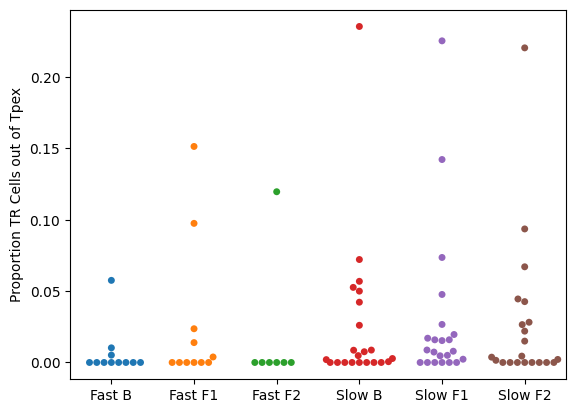

In [35]:
sns.swarmplot(x='timepoint_progression',y='prop_tr_cells',
           data=tr_cells_per_sample,palette='tab10',
           order=['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'])
plt.ylabel('Proportion TR Cells out of Tpex')
plt.xlabel('')

In [36]:
tr_cells_per_sample = adata[~(adata.obs['TR_cell'].isnull())
    ].obs[['sample_x']].value_counts().reset_index()
tr_cells_per_sample.index = tr_cells_per_sample['sample_x']
tr_cells_per_sample = pd.concat([tr_cells_per_sample, cells_per_patient], axis=1)
del tr_cells_per_sample['sample_x']
tr_cells_per_sample = tr_cells_per_sample.reset_index()
tr_cells_per_sample = tr_cells_per_sample.fillna(0)
tr_cells_per_sample['timepoint'] = [i.split('_')[1] for i in tr_cells_per_sample['index']]
tr_cells_per_sample['progression'] = tr_cells_per_sample['index'].map(patient_progression['progression'].to_dict())
tr_cells_per_sample['prop_tr_cells'] = tr_cells_per_sample[0] / tr_cells_per_sample['num_cells']
tr_cells_per_sample['timepoint_progression'] = tr_cells_per_sample['progression'].astype(str) + ' ' + tr_cells_per_sample['timepoint'].astype(str)

/tmp/ipykernel_276854/3159605582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='timepoint_progression',y='prop_tr_cells',


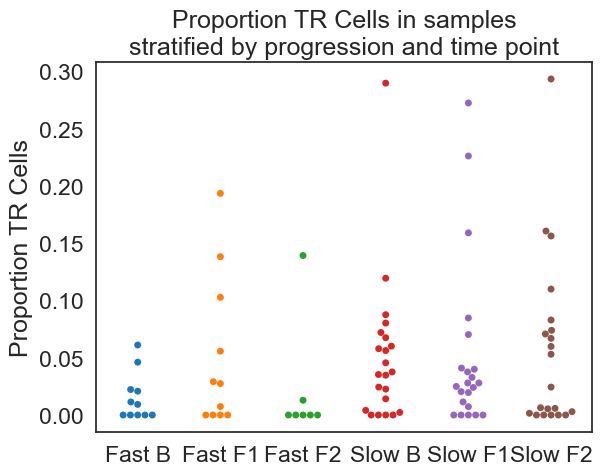

In [37]:
sns.set(font_scale=1.5)
sns.set_style('white')
sns.swarmplot(x='timepoint_progression',y='prop_tr_cells',
           data=tr_cells_per_sample,palette='tab10',
           order=['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'])
plt.ylabel('Proportion TR Cells')
plt.title('Proportion TR Cells in samples\nstratified by progression and time point')
plt.xlabel('')
plt.show()

/tmp/ipykernel_276854/3132751447.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='timepoint_progression',y='prop_tr_cells',


Text(0.5, 0, '')

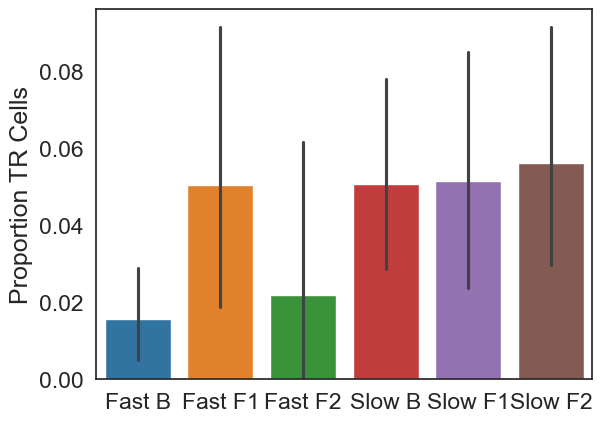

In [38]:
sns.barplot(x='timepoint_progression',y='prop_tr_cells',
           data=tr_cells_per_sample,palette='tab10',
           order=['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'])
plt.ylabel('Proportion TR Cells')
plt.xlabel('')

In [39]:
from scipy.stats import ranksums
_,p_fast_bf1 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast B']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_cells'])
print(p_fast_bf1)

0.30876936771440044


In [40]:
from scipy.stats import ranksums
_,p_fast_f1f2 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast F2']['prop_tr_cells'])
print(p_fast_f1f2)

0.22146183835692945


In [41]:
from scipy.stats import ranksums
_,p_slow_bf1 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow B']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_cells'])
print(p_slow_bf1)

0.5262368666518372


In [42]:
from scipy.stats import ranksums
_,p_slow_f1f2 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow F2']['prop_tr_cells'])
print(p_slow_f1f2)

0.9709277605839084


In [43]:
from scipy.stats import ranksums
_,p_fastb_slowb = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast B']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow B']['prop_tr_cells'])
print(p_fastb_slowb)

0.032467300756707757


In [44]:
from scipy.stats import ranksums
_,p_fastf1_slowf1 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_cells'])
print(p_fastf1_slowf1)

0.8187626378091213


In [45]:
from scipy.stats import ranksums
_,p_fastf2_slowf2 = ranksums(tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Fast F2']['prop_tr_cells'],
         tr_cells_per_sample[tr_cells_per_sample['timepoint_progression'] == 'Slow F2']['prop_tr_cells'])
print(p_fastf2_slowf2)

0.07997317109034316


In [46]:
tr_percent_cells_comparison = {
    'Fast B-Fast F1' : p_fast_bf1,
    'Fast F1-Fast F2' : p_fast_f1f2,
    'Slow B-Slow F1' : p_slow_bf1,
    'Slow F1-Slow F2' : p_slow_f1f2,
    'Fast B-Slow B' : p_fastb_slowb,
    'Fast F1-Slow F1' : p_fastf1_slowf1,
    'Fast F2-Slow F2' : p_fastf2_slowf2
}

In [47]:
clonotypes_per_patient = pd.DataFrame(adata.obs[['sample_x','clonotype_patient']].drop_duplicates()['sample_x'].value_counts())
clonotypes_per_patient.columns = ['num_clonotypes_total']

In [48]:
tr_clonotypes_per_sample = pd.DataFrame(adata[~(adata.obs['TR_cell'].isnull())
    ].obs[['sample_x','clonotype_patient']].drop_duplicates()['sample_x'].value_counts())
tr_clonotypes_per_sample.columns = ['num_clonotypes']
tr_clonotypes_per_sample = pd.concat([tr_clonotypes_per_sample, clonotypes_per_patient], axis=1)
tr_clonotypes_per_sample = tr_clonotypes_per_sample.reset_index()
tr_clonotypes_per_sample = tr_clonotypes_per_sample.fillna(0)
tr_clonotypes_per_sample['timepoint'] = [i.split('_')[1] for i in tr_clonotypes_per_sample['index']]
tr_clonotypes_per_sample['progression'] = tr_clonotypes_per_sample['index'].map(patient_progression['progression'].to_dict())
tr_clonotypes_per_sample['prop_tr_clonotypes'] = tr_clonotypes_per_sample['num_clonotypes'] / tr_clonotypes_per_sample['num_clonotypes_total']
tr_clonotypes_per_sample['timepoint_progression'] = tr_clonotypes_per_sample['progression'].astype(str) + ' ' + tr_clonotypes_per_sample['timepoint'].astype(str)

/tmp/ipykernel_276854/2879085251.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='timepoint_progression',y='prop_tr_clonotypes',


Text(0.5, 14.049999999999999, '')

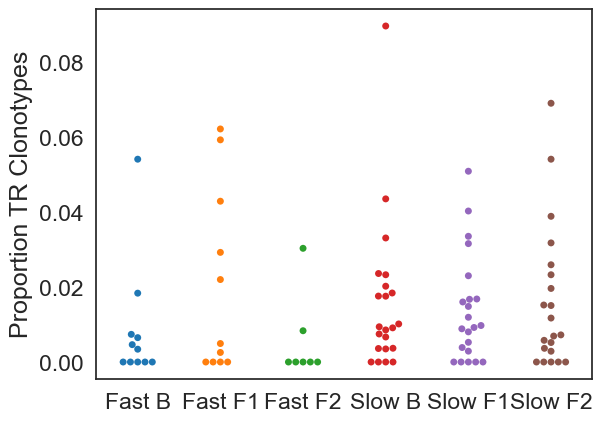

In [49]:
sns.swarmplot(x='timepoint_progression',y='prop_tr_clonotypes',
           data=tr_clonotypes_per_sample,palette='tab10',
           order=['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'])
plt.ylabel('Proportion TR Clonotypes')
plt.xlabel('')

/tmp/ipykernel_276854/1031941592.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='timepoint_progression',y='prop_tr_clonotypes',


Text(0.5, 0, '')

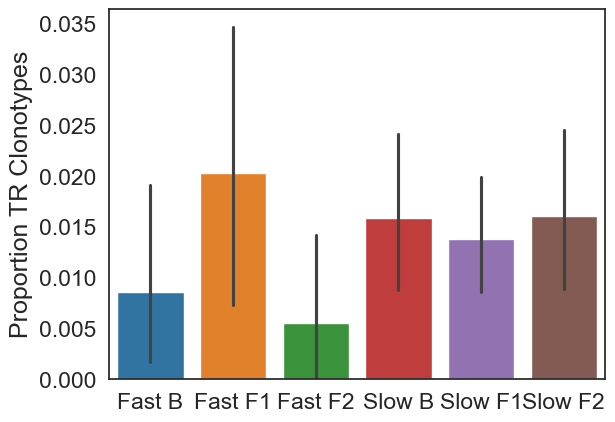

In [50]:
sns.barplot(x='timepoint_progression',y='prop_tr_clonotypes',
           data=tr_clonotypes_per_sample,palette='tab10',
           order=['Fast B','Fast F1','Fast F2','Slow B','Slow F1','Slow F2'])
plt.ylabel('Proportion TR Clonotypes')
plt.xlabel('')

In [51]:
from scipy.stats import ranksums
_,p_fast_bf1 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast B']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_clonotypes'])
print(p_fast_bf1)

0.37536019503501594


In [52]:
from scipy.stats import ranksums
_,p_fast_f1f2 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast F2']['prop_tr_clonotypes'])
print(p_fast_f1f2)

0.18910987176514638


In [53]:
from scipy.stats import ranksums
_,p_slow_bf1 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow B']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_clonotypes'])
print(p_slow_bf1)

0.8144212019041761


In [54]:
from scipy.stats import ranksums
_,p_slow_f1f2 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow F2']['prop_tr_clonotypes'])
print(p_slow_f1f2)

0.9903073466514666


In [55]:
from scipy.stats import ranksums
_,p_fastb_slowb = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast B']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow B']['prop_tr_clonotypes'])
print(p_fastb_slowb)

0.0613058122500189


In [56]:
from scipy.stats import ranksums
_,p_fastf1_slowf1 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast F1']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow F1']['prop_tr_clonotypes'])
print(p_fastf1_slowf1)

0.9695366269904038


In [57]:
from scipy.stats import ranksums
_,p_fastf2_slowf2 = ranksums(tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Fast F2']['prop_tr_clonotypes'],
         tr_clonotypes_per_sample[tr_clonotypes_per_sample['timepoint_progression'] == 'Slow F2']['prop_tr_clonotypes'])
print(p_fastf2_slowf2)

0.07997317109034316


In [58]:
tr_percent_clonotypes_comparison = {
    'Fast B-Fast F1' : p_fast_bf1,
    'Fast F1-Fast F2' : p_fast_f1f2,
    'Slow B-Slow F1' : p_slow_bf1,
    'Slow F1-Slow F2' : p_slow_f1f2,
    'Fast B-Slow B' : p_fastb_slowb,
    'Fast F1-Slow F1' : p_fastf1_slowf1,
    'Fast F2-Slow F2' : p_fastf2_slowf2
}

In [59]:
adata.obs['TR_nonTR'] = adata.obs['TR_cell'].fillna('non TR')

In [60]:
adata_tpex = adata[adata.obs['annot_final'] == 'GZMK+ CD8 T progenitor ex Cell']

In [61]:
prop_cells = {}
prop_clonotypes = {}
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    prop_cells[i] = len(temp[~temp.obs['TR_cell'].isnull()]) / len(temp)
    prop_clonotypes[i] = len(temp[~temp.obs['TR_cell'].isnull()].obs['clonotype_patient'].unique()) / len(temp.obs['clonotype_patient'].unique())

In [62]:
(pd.Series(prop_cells) > 0).map({False: 0, True : 1})

E30_F1    0
E26_F2    1
E15_F1    1
E21_B     1
E43_F1    1
         ..
E24_F2    1
E23_F2    1
E19_F1    1
E18_F1    1
E29_F1    1
Length: 94, dtype: int64

In [63]:
prop_cells_df = pd.DataFrame((pd.Series(prop_cells) > 0).map({False: 0, True : 1}))
prop_cells_df.columns = ['TR Cell Proportion']
prop_cells_df['Progression'] = prop_cells_df.index.map(patient_progression['progression'].to_dict())
prop_cells_df['Timepoint'] = [i.split('_')[1] for i in prop_cells_df.index]
prop_cells_df_patient = prop_cells_df.copy()
prop_cells_df.index = prop_cells_df['Progression'] + ' ' + prop_cells_df['Timepoint']
del prop_cells_df['Progression']
del prop_cells_df['Timepoint']
prop_cells_df['Non-TR Cell Proportion'] = 1 - prop_cells_df['TR Cell Proportion']
prop_cells_df = prop_cells_df.groupby(prop_cells_df.index).sum()
contingency_table = prop_cells_df.copy()
prop_cells_df = prop_cells_df.div(prop_cells_df.sum(axis=1), axis=0)

In [64]:
prop_cells_df.columns = ['TR Patients','non-TR Patients']

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Fast B'),
  Text(1, 0, 'Fast F1'),
  Text(2, 0, 'Fast F2'),
  Text(3, 0, 'Slow B'),
  Text(4, 0, 'Slow F1'),
  Text(5, 0, 'Slow F2')])

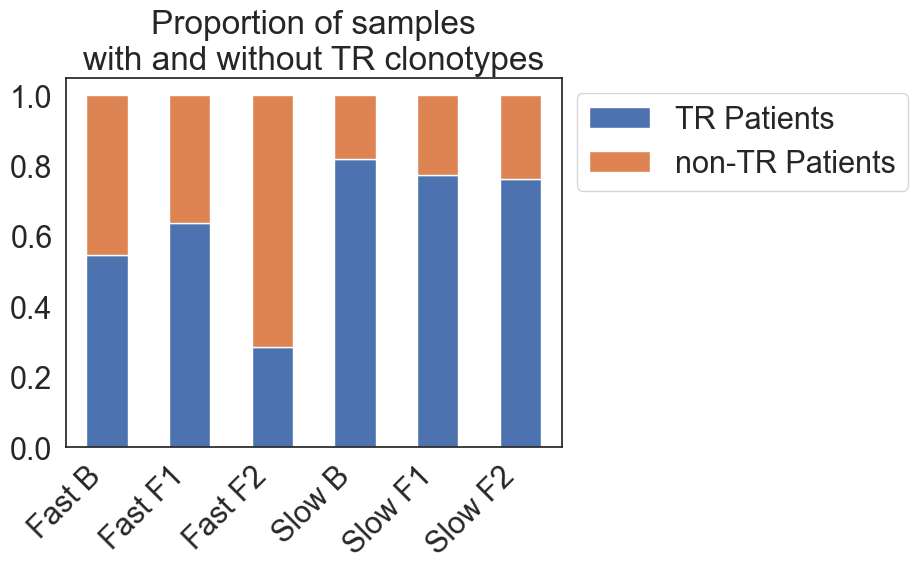

In [65]:
sns.set(font_scale=2)
sns.set_style('white')
prop_cells_df.plot(kind='bar',stacked=True)
plt.title('Proportion of samples\nwith and without TR clonotypes')
plt.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation=45,ha='right')

In [66]:
from scipy.stats import fisher_exact

In [67]:
_, p_fast_bf1 = fisher_exact(contingency_table.loc[['Fast B','Fast F1']],alternative='two-sided')
print(p_fast_bf1)

1.0


In [68]:
_, p_fast_f1f2 = fisher_exact(contingency_table.loc[['Fast F1','Fast F2']],alternative='two-sided')
print(p_fast_f1f2)

0.334841628959276


In [69]:
_, p_slow_bf1 = fisher_exact(contingency_table.loc[['Slow B','Slow F1']],alternative='two-sided')
print(p_slow_bf1)

1.0


In [70]:
_, p_slow_f1f2 = fisher_exact(contingency_table.loc[['Slow F1','Slow F2']],alternative='two-sided')
print(p_slow_f1f2)

1.0


In [71]:
_, p_fastb_slowb = fisher_exact(contingency_table.loc[['Fast B','Slow B']],alternative='two-sided')
print(p_fastb_slowb)

0.1210447505775648


In [72]:
_, p_fastf1_slowf1 = fisher_exact(contingency_table.loc[['Fast F1','Slow F1']],alternative='two-sided')
print(p_fastf1_slowf1)

0.43757593907760756


In [73]:
_, p_fastf2_slowf2 = fisher_exact(contingency_table.loc[['Fast F2','Slow F2']],alternative='two-sided')
print(p_fastf2_slowf2)

0.06273436708219315


In [74]:
tr_percent_samples_with_comparison = {
    'Fast B-Fast F1' : p_fast_bf1,
    'Fast F1-Fast F2' : p_fast_f1f2,
    'Slow B-Slow F1' : p_slow_bf1,
    'Slow F1-Slow F2' : p_slow_f1f2,
    'Fast B-Slow B' : p_fastb_slowb,
    'Fast F1-Slow F1' : p_fastf1_slowf1,
    'Fast F2-Slow F2' : p_fastf2_slowf2
}

In [75]:
from scipy.stats import fisher_exact

Text(0.5, 1.0, 'Proportion of Slow B Samples with and without TR cells')

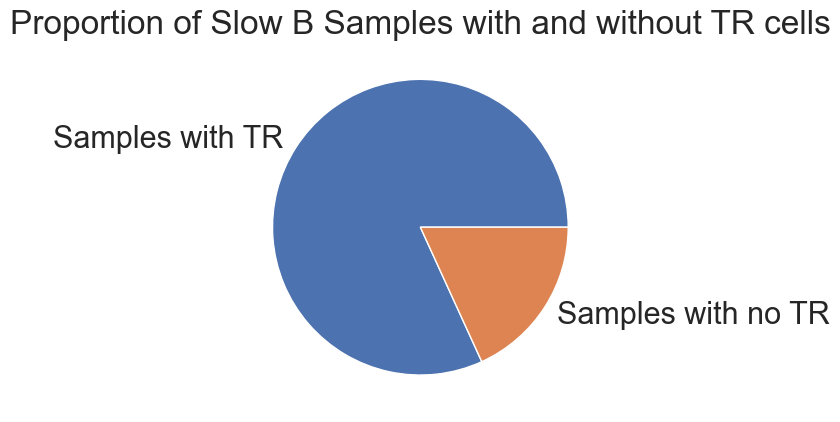

In [76]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Slow') & (
    prop_cells_df_patient['Timepoint'] == 'B'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with TR','Samples with no TR'])
plt.title('Proportion of Slow B Samples with and without TR cells')

Text(0.5, 1.0, 'Proportion of Slow F1 Samples with and without TR cells')

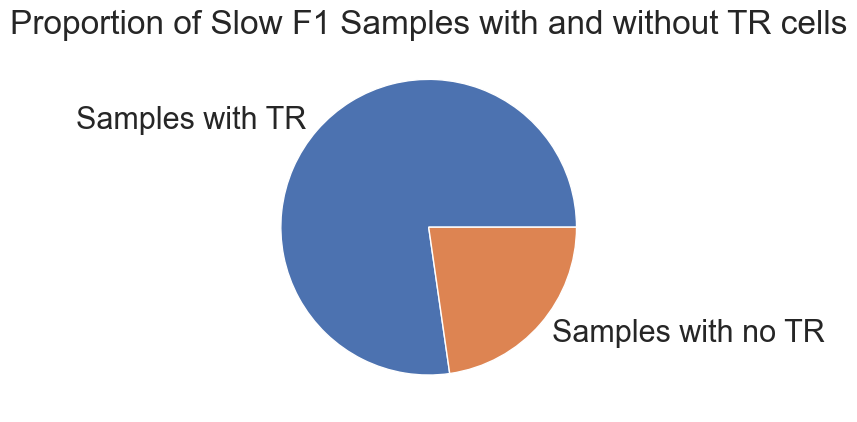

In [77]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Slow') & (
    prop_cells_df_patient['Timepoint'] == 'F1'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with TR','Samples with no TR'])
plt.title('Proportion of Slow F1 Samples with and without TR cells')

Text(0.5, 1.0, 'Proportion of Slow F2 Samples with and without TR cells')

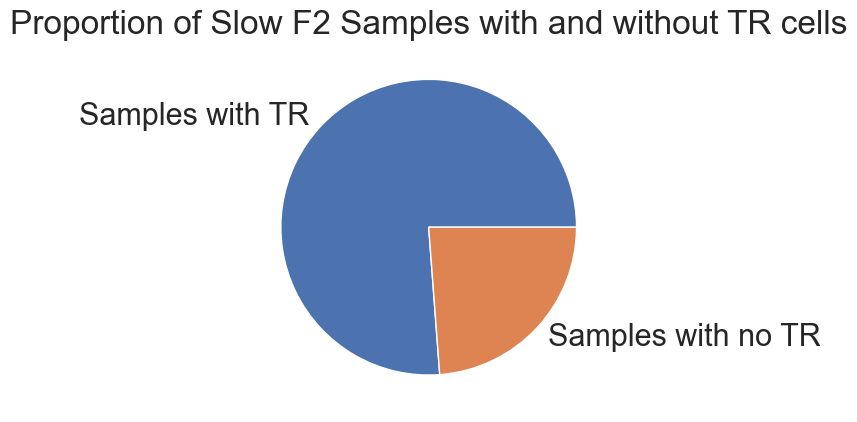

In [78]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Slow') & (
    prop_cells_df_patient['Timepoint'] == 'F2'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with TR','Samples with no TR'])
plt.title('Proportion of Slow F2 Samples with and without TR cells')

Text(0.5, 1.0, 'Proportion of Fast B Samples with and without TR cells')

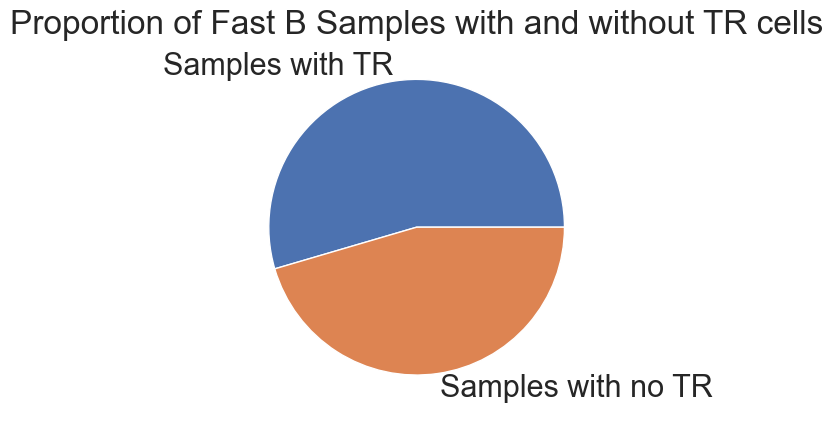

In [79]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Fast') & (
    prop_cells_df_patient['Timepoint'] == 'B'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with TR','Samples with no TR'])
plt.title('Proportion of Fast B Samples with and without TR cells')

Text(0.5, 1.0, 'Proportion of Fast F1 Samples with and without TR cells')

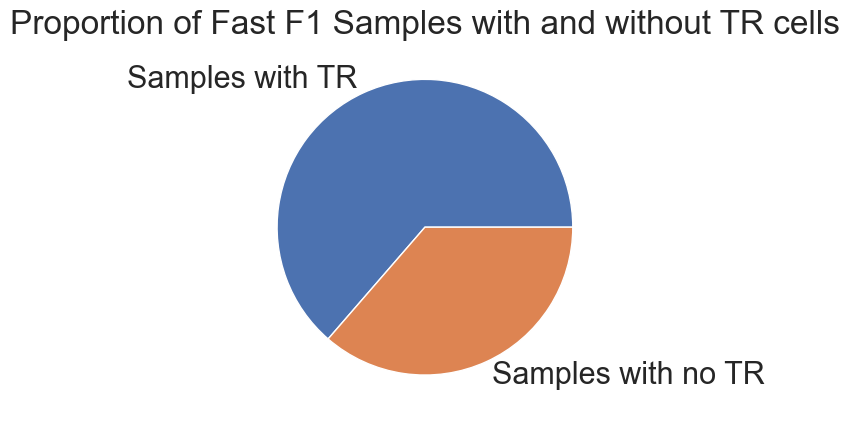

In [80]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Fast') & (
    prop_cells_df_patient['Timepoint'] == 'F1'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with TR','Samples with no TR'])
plt.title('Proportion of Fast F1 Samples with and without TR cells')

Text(0.5, 1.0, 'Proportion of Fast F2 Samples with and without TR cells')

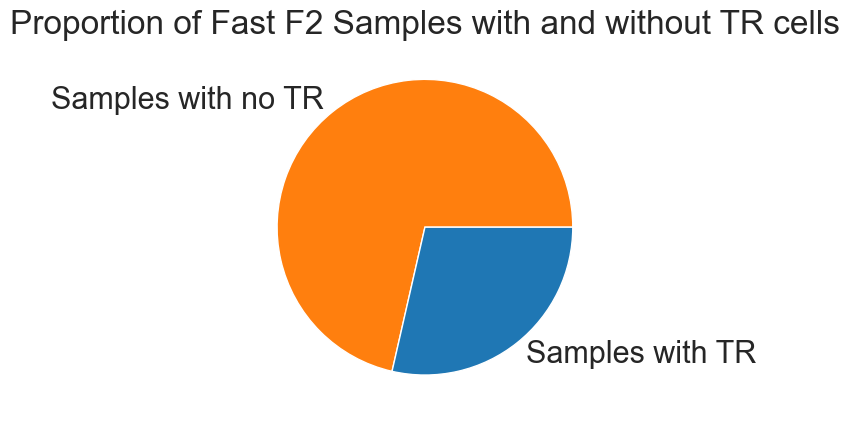

In [81]:
plt.pie(prop_cells_df_patient[(prop_cells_df_patient['Progression'] == 'Fast') & (
    prop_cells_df_patient['Timepoint'] == 'F2'
)]['TR Cell Proportion'].value_counts(),
        labels=['Samples with no TR','Samples with TR'],colors=['tab:orange','tab:blue'])
plt.title('Proportion of Fast F2 Samples with and without TR cells')

In [82]:
comparisons_df = pd.concat([pd.Series(tr_percent_cells_comparison),
           pd.Series(tr_percent_clonotypes_comparison),
           pd.Series(tr_percent_samples_with_comparison)],axis=1)
comparisons_df.columns = ['TR Percent Cells',
                          'TR Percent Clonotypes',
                          'Proportion Samples With TR']
comparisons_df.to_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tr_statistical_comparisons.csv')

In [83]:
bf1_shared_clones = {}
f1f2_shared_clones = {}
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    if len(temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1)].obs['clonotype_patient'].unique()) > 0:
        bf1_shared_clones[i] = len(temp[~(temp.obs['TR_cell'].isnull()) & (temp.obs['clonotype_patient'].isin(shared_clones_bf1))].obs['clonotype_patient'].unique()) / len(temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1)].obs['clonotype_patient'].unique())
    if len(temp[temp.obs['clonotype_patient'].isin(shared_clones_f1f2)].obs['clonotype_patient'].unique()) > 0:
        f1f2_shared_clones[i] = len(temp[~(temp.obs['TR_cell'].isnull()) & (temp.obs['clonotype_patient'].isin(shared_clones_f1f2))].obs['clonotype_patient'].unique()) / len(temp[temp.obs['clonotype_patient'].isin(shared_clones_f1f2)].obs['clonotype_patient'].unique())

In [84]:
proportion_tr_clones_bf1 = (pd.Series([i.split('_')[1] for i in shared_clones_bf1 if i in tr_clonotype_patient]).value_counts() / pd.Series([i.split('_')[1] for i in shared_clones_bf1]).value_counts()).fillna(0)
proportion_tr_clones_f1f2 = (pd.Series([i.split('_')[1] for i in shared_clones_f1f2 if i in tr_clonotype_patient]).value_counts() / pd.Series([i.split('_')[1] for i in shared_clones_f1f2]).value_counts()).fillna(0)

In [85]:
proportion_shared_tr_clones = pd.concat([proportion_tr_clones_bf1,proportion_tr_clones_f1f2],axis=1)
proportion_shared_tr_clones.columns = ['B-F1','F1-F2']

Text(0.5, 1.0, 'Proportion of shared clonotypes that are TR')

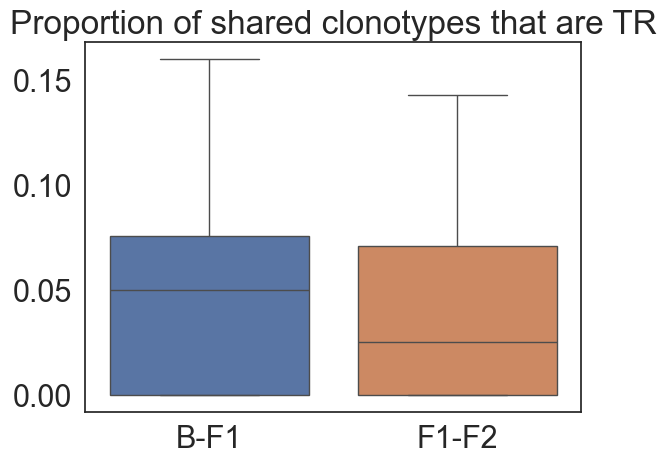

In [86]:
sns.boxplot(proportion_shared_tr_clones[['B-F1','F1-F2']],showfliers=False)
plt.title('Proportion of shared clonotypes that are TR')

In [87]:
_, p_bf1_f1f2 = ranksums(proportion_shared_tr_clones['B-F1'],
         proportion_shared_tr_clones['F1-F2'],nan_policy='omit')
print(p_bf1_f1f2)

0.47538399219176164


In [88]:
clonotype_timepoint = adata.obs[['clonotype_patient','timepoint']].value_counts(
    
).reset_index().pivot(columns='timepoint',index='clonotype_patient',values=0).fillna(0)

clonotype_timepoint = clonotype_timepoint.apply(lambda x: np.where(x != 0, 1, 0))

In [89]:
b_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f1_clonotypes = clonotype_timepoint[(clonotype_timepoint['B'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f2_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['B'] == 0)].index.tolist()

In [90]:
proportion_tr_clones_nonshared_b = (pd.Series([i.split('_')[1] for i in b_clonotypes if i in tr_clonotype_patient]).value_counts() / pd.Series([i.split('_')[1] for i in b_clonotypes]).value_counts()).fillna(0)
proportion_tr_clones_nonshared_f1 = (pd.Series([i.split('_')[1] for i in f1_clonotypes if i in tr_clonotype_patient]).value_counts() / pd.Series([i.split('_')[1] for i in f1_clonotypes]).value_counts()).fillna(0)
proportion_tr_clones_nonshared_f2 = (pd.Series([i.split('_')[1] for i in f2_clonotypes if i in tr_clonotype_patient]).value_counts() / pd.Series([i.split('_')[1] for i in f2_clonotypes]).value_counts()).fillna(0)

In [91]:
proportion_nonshared_tr_clones = pd.concat([proportion_tr_clones_nonshared_b,
                                            proportion_tr_clones_nonshared_f1,
                                            proportion_tr_clones_nonshared_f2],axis=1)
proportion_nonshared_tr_clones.columns = ['B','F1','F2']

Text(0.5, 1.0, 'Proportion of non-shared clonotypes that are TR')

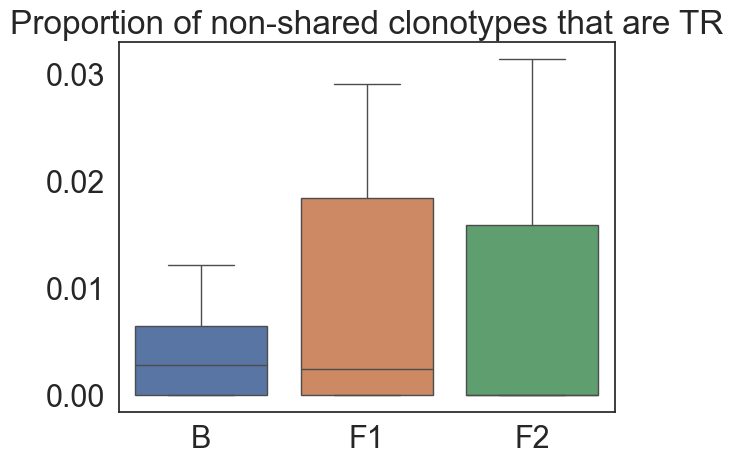

In [92]:
sns.boxplot(proportion_nonshared_tr_clones[['B','F1','F2']],showfliers=False)
plt.title('Proportion of non-shared clonotypes that are TR')

In [93]:
_,p_bf1 = ranksums(proportion_nonshared_tr_clones['B'],
         proportion_nonshared_tr_clones['F1'],nan_policy='omit')
print(p_bf1)

0.5509496792306845


In [94]:
_,p_bf2 = ranksums(proportion_nonshared_tr_clones['B'],
         proportion_nonshared_tr_clones['F2'],nan_policy='omit')
print(p_bf2)

0.8735088737650667


In [95]:
_,p_f1f2 = ranksums(proportion_nonshared_tr_clones['F1'],
         proportion_nonshared_tr_clones['F2'],nan_policy='omit')
print(p_f1f2)

0.4218291379207765


Text(0.5, 1.0, 'Proportion of TR clonotypes coming from each patient')

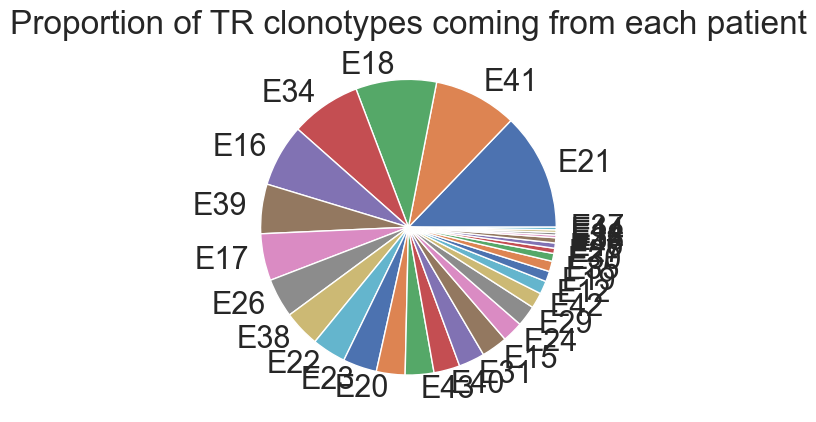

In [96]:
labels = pd.Series([i.split('_')[1] for i in tr_clonotype_patient]).value_counts().index
plt.pie(pd.Series([i.split('_')[1] for i in tr_clonotype_patient]).value_counts(),labels=labels)
plt.title('Proportion of TR clonotypes coming from each patient')

Text(0.5, 1.0, 'Proportion of TR cells coming from each patient')

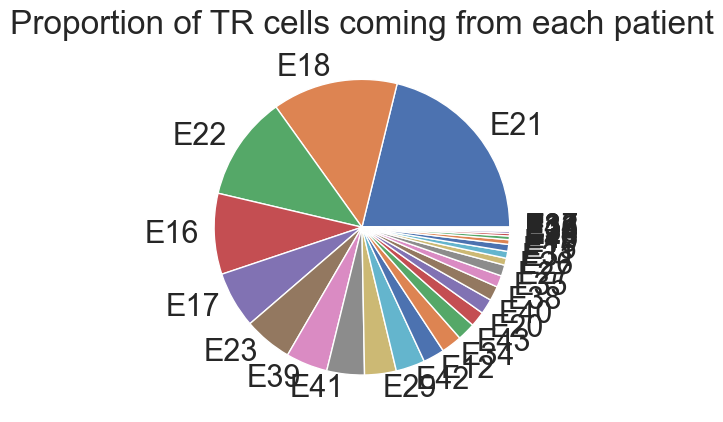

In [97]:
temp = adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs['patient'].value_counts()
labels = temp.index
plt.pie(temp,labels=labels)
plt.title('Proportion of TR cells coming from each patient')

In [98]:
shared_clones_bf1f2 = list(set(shared_clones_bf1) & set(shared_clones_f1f2))

In [99]:
shared_clones_bf1_only = [i for i in shared_clones_bf1 if i not in shared_clones_bf1f2]
shared_clones_f1f2_only = [i for i in shared_clones_f1f2 if i not in shared_clones_bf1f2]

In [100]:
colors = {
    'All Timepoints Shared' : 'tab:blue',
    'B-F1 Shared Only' : 'tab:orange',
    'F1-F2 Shared Only' : 'tab:green',
    'B Only' : 'tab:red',
    'F1 Only' : 'tab:purple',
    'F2 Only' : 'tab:brown',
    'B-F2 Shared Only' : 'tab:pink'
}

In [101]:
tr_clone_category = []
for i in tr_clonotype_patient:
    if i in shared_clones_bf1f2:
        tr_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_clone_category.append('B Only')
    elif i in f1_clonotypes:
        tr_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_clone_category.append('F2 Only')
    else:
        tr_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of TR clonotypes by timepoint sharing')

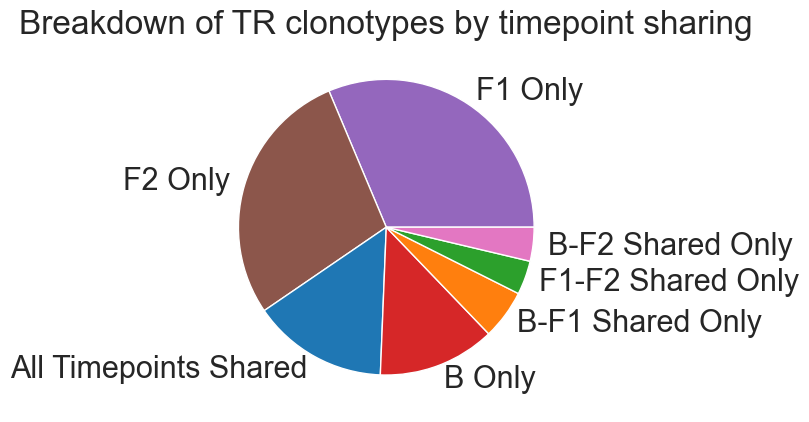

In [102]:
labels = pd.Series(tr_clone_category).value_counts().index
plt.pie(pd.Series(tr_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(tr_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of TR clonotypes by timepoint sharing')

In [103]:
tr_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        tr_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_clone_category.append('B Only')
    elif i in f1_clonotypes:
        tr_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_clone_category.append('F2 Only')
    else:
        tr_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of TR clonotypes by timepoint sharing, slow')

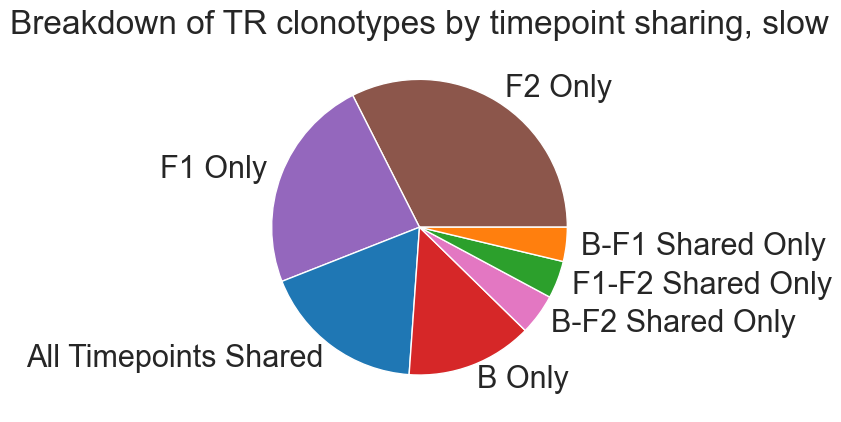

In [104]:
labels = pd.Series(tr_clone_category).value_counts().index
plt.pie(pd.Series(tr_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(tr_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of TR clonotypes by timepoint sharing, slow')

In [105]:
tr_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        tr_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_clone_category.append('B Only')
    elif i in f1_clonotypes:
        tr_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_clone_category.append('F2 Only')
    else:
        tr_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of TR clonotypes by timepoint sharing, fast')

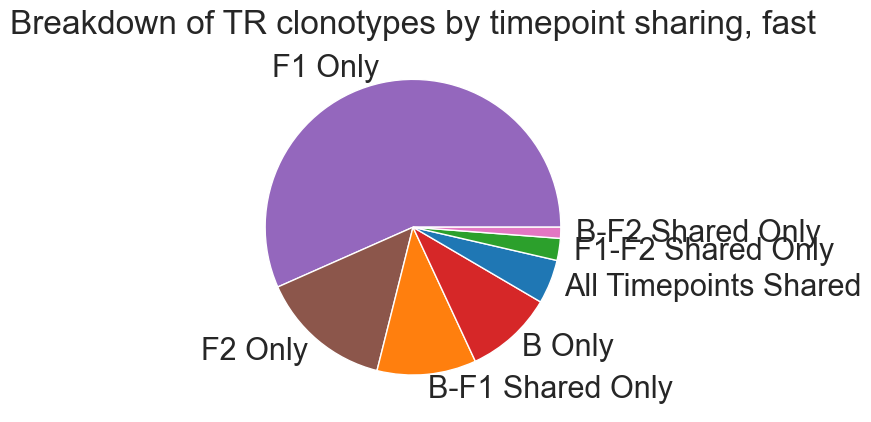

In [106]:
labels = pd.Series(tr_clone_category).value_counts().index
plt.pie(pd.Series(tr_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(tr_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of TR clonotypes by timepoint sharing, fast')

In [107]:
tr_clone_category = []
for i in adata.obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        tr_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_clone_category.append('B Only')
    elif i in f1_clonotypes:
        tr_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_clone_category.append('F2 Only')
    else:
        tr_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of all clonotypes by timepoint sharing')

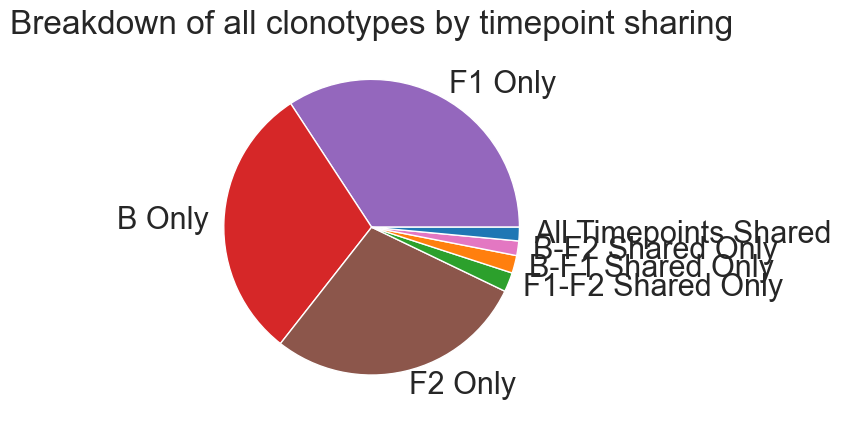

In [108]:
labels = pd.Series(tr_clone_category).value_counts().index
plt.pie(pd.Series(tr_clone_category).value_counts(),labels=labels,
       colors=[colors[i] for i in pd.Series(tr_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of all clonotypes by timepoint sharing')

In [109]:
tr_cell_category = []
for i in adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs['clonotype_patient']:
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_cell_category.append('B Only')
    elif i in f1_clonotypes:
        tr_cell_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_cell_category.append('F2 Only')
    else:
        tr_cell_category.append('B-F2 Shared Only')

In [110]:
colors = {
    'All Timepoints Shared' : plt.matplotlib.colors.to_rgba('tab:blue', alpha=1),
    'B-F1 Shared Only' : plt.matplotlib.colors.to_rgba('tab:orange', alpha=1),
    'F1-F2 Shared Only' : plt.matplotlib.colors.to_rgba('tab:green', alpha=1),
    'B Only' : plt.matplotlib.colors.to_rgba('tab:red', alpha=0.1),
    'F1 Only' : plt.matplotlib.colors.to_rgba('tab:purple', alpha=0.1),
    'F2 Only' : plt.matplotlib.colors.to_rgba('tab:brown', alpha=0.1),
    'B-F2 Shared Only' : plt.matplotlib.colors.to_rgba('tab:pink', alpha=1)
}

In [111]:
pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F2 Shared Only',
                                               'B-F1 Shared Only','F1-F2 Shared Only','F2 Only',
                                                'F1 Only','B Only']]

All Timepoints Shared    2015
B-F2 Shared Only          343
B-F1 Shared Only          125
F1-F2 Shared Only          77
F2 Only                   510
F1 Only                   342
B Only                    140
dtype: int64

Text(0.5, 1.0, 'Breakdown of TR cells by timepoint sharing')

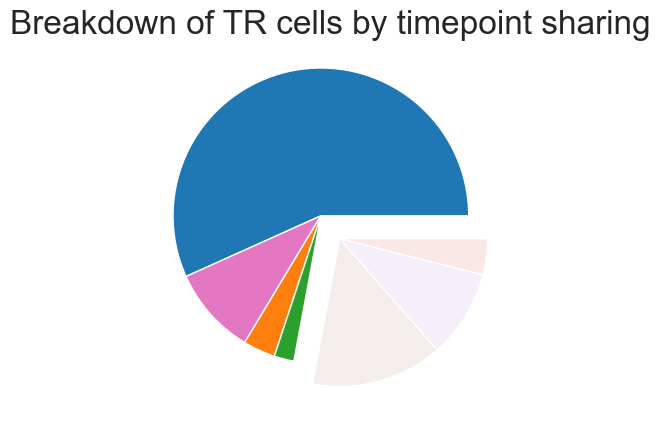

In [112]:
wedges, _ = plt.pie(pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F2 Shared Only',
                                               'B-F1 Shared Only','F1-F2 Shared Only','F2 Only',
                                                'F1 Only','B Only']],
       colors=[colors[i] for i in ['All Timepoints Shared','B-F2 Shared Only',
                                               'B-F1 Shared Only','F1-F2 Shared Only','F2 Only',
                                                'F1 Only','B Only']]
       )
groups = [[0,1,2,3],[4,5,6]]
radfraction = 0.1
for group in groups:
    ang = np.deg2rad((wedges[group[-1]].theta2 + wedges[group[0]].theta1) / 2)
    for j in group:
        center = radfraction * wedges[j].r * np.array([np.cos(ang), np.sin(ang)])
        wedges[j].set_center(center)
plt.title('Breakdown of TR cells by timepoint sharing')

In [113]:
tr_sharing_status = pd.concat(
    [adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs['clonotype_patient'].reset_index(drop=True),
    pd.Series(tr_cell_category)],axis=1)
tr_sharing_status.columns = ['clonotype_patient','sharing_status']

In [114]:
tr_sharing_status.to_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tr_sharing.csv',index=False)

In [115]:
tr_cell_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient']:
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_cell_category.append('B Only')
    elif i in f1_clonotypes:
        tr_cell_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_cell_category.append('F2 Only')
    else:
        tr_cell_category.append('B-F2 Shared Only')

In [116]:
pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F2 Shared Only',
                                            'B-F1 Shared Only','F1-F2 Shared Only',
                                           'F2 Only','F1 Only','B Only']]

All Timepoints Shared    1863
B-F2 Shared Only          329
B-F1 Shared Only           72
F1-F2 Shared Only          58
F2 Only                   385
F1 Only                   153
B Only                    123
dtype: int64

Text(0.5, 1.0, 'Breakdown of TR cells by timepoint sharing, slow')

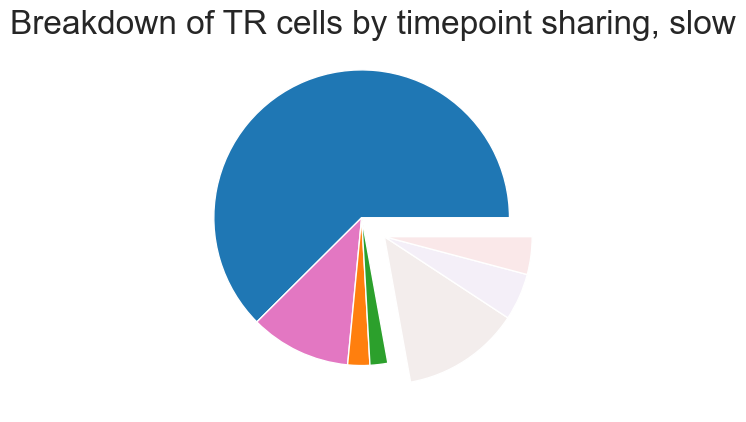

In [117]:
labels = pd.Series(tr_cell_category).value_counts().index
wedges, _ = plt.pie(pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F2 Shared Only',
                                            'B-F1 Shared Only','F1-F2 Shared Only',
                                           'F2 Only','F1 Only','B Only']],
       colors=[colors[i] for i in ['All Timepoints Shared','B-F2 Shared Only',
                                            'B-F1 Shared Only','F1-F2 Shared Only',
                                           'F2 Only','F1 Only','B Only']])
groups = [[0,1,2,3],[4,5,6]]
radfraction = 0.1
for group in groups:
    ang = np.deg2rad((wedges[group[-1]].theta2 + wedges[group[0]].theta1) / 2)
    for j in group:
        center = radfraction * wedges[j].r * np.array([np.cos(ang), np.sin(ang)])
        wedges[j].set_center(center)
plt.title('Breakdown of TR cells by timepoint sharing, slow')

In [118]:
tr_cell_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient']:
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_cell_category.append('B Only')
    elif i in f1_clonotypes:
        tr_cell_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_cell_category.append('F2 Only')
    else:
        tr_cell_category.append('B-F2 Shared Only')

In [119]:
pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F1 Shared Only',
                                           'F1-F2 Shared Only','B-F2 Shared Only','F1 Only',
                                           'F2 Only','B Only']]

All Timepoints Shared    152
B-F1 Shared Only          53
F1-F2 Shared Only         19
B-F2 Shared Only          14
F1 Only                  189
F2 Only                  125
B Only                    17
dtype: int64

Text(0.5, 1.0, 'Breakdown of TR cells by timepoint sharing, fast')

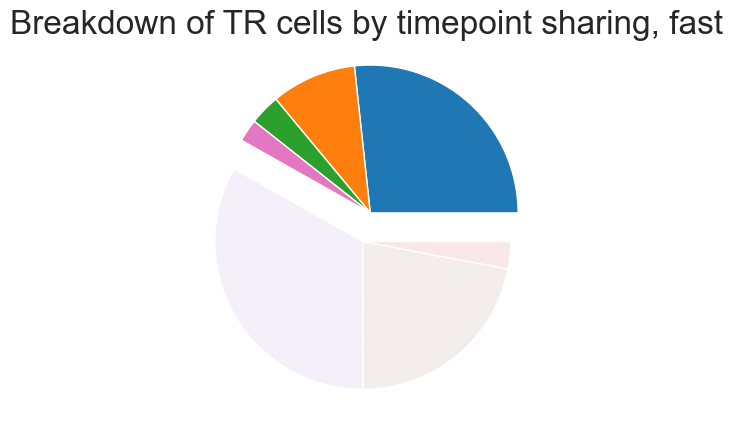

In [120]:
labels = pd.Series(tr_cell_category).value_counts().index
wedges, _ = plt.pie(pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','B-F1 Shared Only',
                                           'F1-F2 Shared Only','B-F2 Shared Only','F1 Only',
                                           'F2 Only','B Only']],
       colors=[colors[i] for i in ['All Timepoints Shared','B-F1 Shared Only',
                                           'F1-F2 Shared Only','B-F2 Shared Only','F1 Only',
                                           'F2 Only','B Only']])
groups = [[0,1,2,3],[4,5,6]]
radfraction = 0.1
for group in groups:
    ang = np.deg2rad((wedges[group[-1]].theta2 + wedges[group[0]].theta1) / 2)
    for j in group:
        center = radfraction * wedges[j].r * np.array([np.cos(ang), np.sin(ang)])
        wedges[j].set_center(center)
plt.title('Breakdown of TR cells by timepoint sharing, fast')

In [121]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([], [])

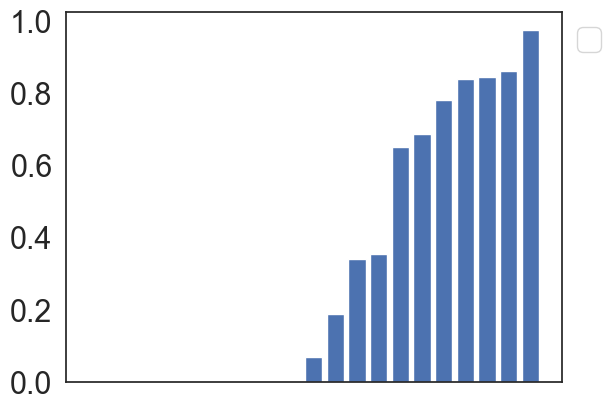

In [122]:
patient_list = []
tr_cell_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient']:
    patient_list.append(i.split('_')[1])
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('Other')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('Other')
    elif i in b_clonotypes:
        tr_cell_category.append('Other')
    elif i in f1_clonotypes:
        tr_cell_category.append('Other')
    elif i in f2_clonotypes:
        tr_cell_category.append('Other')
    else:
        tr_cell_category.append('Other')
temp_slow = pd.DataFrame({
    'Patient' : pd.Series(patient_list),
    'TR Cell Category' : pd.Series(tr_cell_category)}).groupby('Patient').value_counts().reset_index().pivot(index='Patient',
                                                                                                            columns='TR Cell Category',
                                                                                                            values=0).fillna(0).sort_values(by='All Timepoints Shared')
temp_slow = temp_slow.div(temp_slow.sum(axis=1),axis=0)
temp_slow = temp_slow.sort_values(by='All Timepoints Shared')
plt.bar(data=temp_slow,x=temp_slow.index,height='All Timepoints Shared')
plt.legend(bbox_to_anchor=(1,1))
plt.xticks([])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([], [])

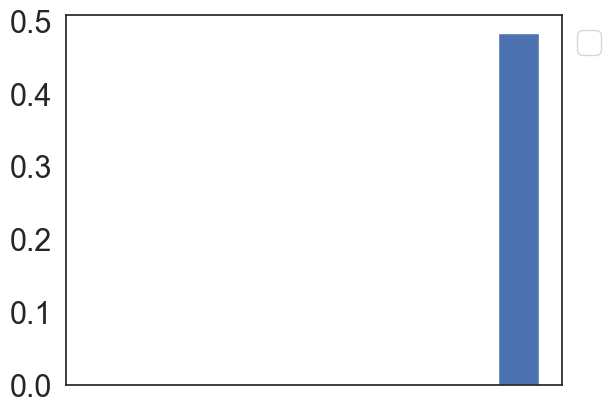

In [123]:
patient_list = []
tr_cell_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient']:
    patient_list.append(i.split('_')[1])
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('Other')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('Other')
    elif i in b_clonotypes:
        tr_cell_category.append('Other')
    elif i in f1_clonotypes:
        tr_cell_category.append('Other')
    elif i in f2_clonotypes:
        tr_cell_category.append('Other')
    else:
        tr_cell_category.append('Other')
temp_fast = pd.DataFrame({
    'Patient' : pd.Series(patient_list),
    'TR Cell Category' : pd.Series(tr_cell_category)}).groupby('Patient').value_counts().reset_index().pivot(index='Patient',
                                                                                                            columns='TR Cell Category',
                                                                                                            values=0).fillna(0).sort_values(by='All Timepoints Shared')
temp_fast = temp_fast.div(temp_fast.sum(axis=1),axis=0)
temp_fast = temp_fast.sort_values(by='All Timepoints Shared')
plt.bar(data=temp_fast,x=temp_fast.index,height='All Timepoints Shared')
plt.legend(bbox_to_anchor=(1,1))
plt.xticks([])

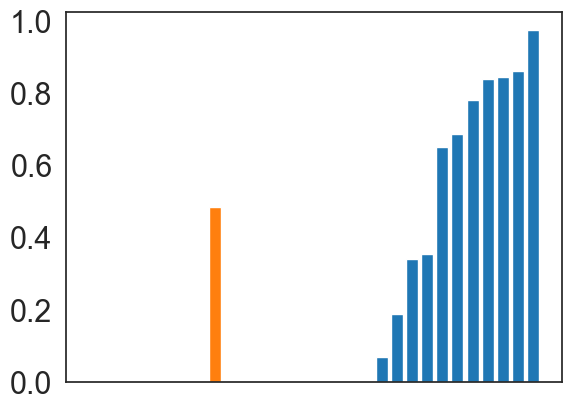

In [124]:
temp_all = pd.concat([temp_fast,temp_slow],axis=0)
temp_all = temp_all.div(temp_all.sum(axis=1),axis=0)
temp_all['Progression'] = temp_all.index.astype(str).map(patient_progression)
temp_all['Progression Color'] = temp_all['Progression'].map({'Fast' : 'tab:orange',
                                                             'Slow' : 'tab:blue'})
plt.bar(data=temp_all,x=temp_all.index,height='All Timepoints Shared',
       color='Progression Color',label='Progression')
plt.xticks([])
plt.show()

/tmp/ipykernel_276854/1207964539.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=temp_all,x='Progression',y='All Timepoints Shared',


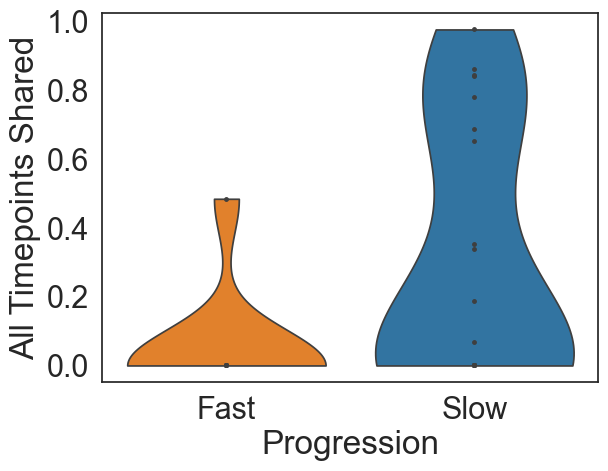

In [125]:
sns.violinplot(data=temp_all,x='Progression',y='All Timepoints Shared',
              palette={'Fast':'tab:orange','Slow':'tab:blue'},cut=0,inner='points')
plt.show()

In [126]:
from scipy.stats import ranksums
ranksums(temp_all[temp_all['Progression'] == 'Slow']['All Timepoints Shared'],
temp_all[temp_all['Progression'] == 'Fast']['All Timepoints Shared'])

RanksumsResult(statistic=1.8328794299157527, pvalue=0.06682050342601834)

In [127]:
tr_cell_category = []
for i in adata.obs['clonotype_patient']:
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        tr_cell_category.append('B Only')
    elif i in f1_clonotypes:
        tr_cell_category.append('F1 Only')
    elif i in f2_clonotypes:
        tr_cell_category.append('F2 Only')
    else:
        tr_cell_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of all cells by timepoint sharing')

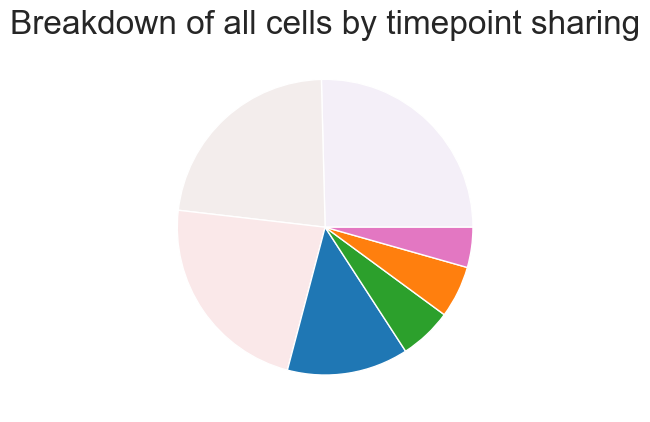

In [128]:
labels = pd.Series(tr_cell_category).value_counts().index
plt.pie(pd.Series(tr_cell_category).value_counts(),
       colors=[colors[i] for i in pd.Series(tr_cell_category).value_counts().index.tolist()])
plt.title('Breakdown of all cells by timepoint sharing')

In [129]:
tr_cell_category = []
for i in adata.obs['clonotype_patient']:
    if i not in tr_clonotype_patient:
        if i in shared_clones_bf1f2:
            tr_cell_category.append('All Timepoints Shared')
        elif i in shared_clones_bf1_only:
            tr_cell_category.append('B-F1 Shared Only')
        elif i in shared_clones_f1f2_only:
            tr_cell_category.append('F1-F2 Shared Only')
        elif i in b_clonotypes:
            tr_cell_category.append('B Only')
        elif i in f1_clonotypes:
            tr_cell_category.append('F1 Only')
        elif i in f2_clonotypes:
            tr_cell_category.append('F2 Only')
        else:
            tr_cell_category.append('B-F2 Shared Only')

In [130]:
pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','F1-F2 Shared Only',
                                            'B-F1 Shared Only','B-F2 Shared Only',
                                            'F2 Only','B Only','F1 Only']]

All Timepoints Shared     5351
F1-F2 Shared Only         3120
B-F1 Shared Only          3030
B-F2 Shared Only          2096
F2 Only                  12128
B Only                   12472
F1 Only                  13757
dtype: int64

Text(0.5, 1.0, 'Breakdown of all non-TR cells by timepoint sharing')

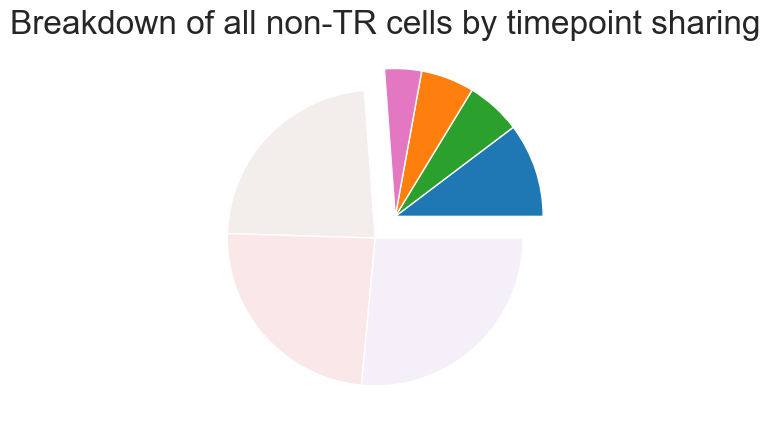

In [131]:
labels = pd.Series(tr_cell_category).value_counts().index
wedges, _ =plt.pie(pd.Series(tr_cell_category).value_counts()[['All Timepoints Shared','F1-F2 Shared Only',
                                            'B-F1 Shared Only','B-F2 Shared Only',
                                            'F2 Only','B Only','F1 Only']],
       colors=[colors[i] for i in ['All Timepoints Shared','F1-F2 Shared Only',
                                            'B-F1 Shared Only','B-F2 Shared Only',
                                            'F2 Only','B Only','F1 Only']])
groups = [[0,1,2,3],[4,5,6]]
radfraction = 0.1
for group in groups:
    ang = np.deg2rad((wedges[group[-1]].theta2 + wedges[group[0]].theta1) / 2)
    for j in group:
        center = radfraction * wedges[j].r * np.array([np.cos(ang), np.sin(ang)])
        wedges[j].set_center(center)
plt.title('Breakdown of all non-TR cells by timepoint sharing')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([], [])

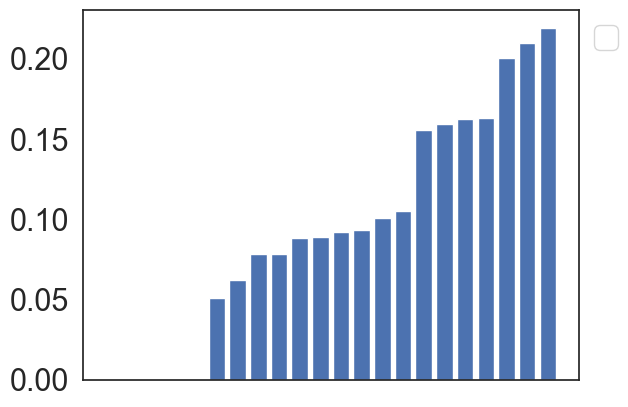

In [132]:
patient_list = []
tr_cell_category = []
for i in adata[~(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient']:
    patient_list.append(i.split('_')[1])
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('Other')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('Other')
    elif i in b_clonotypes:
        tr_cell_category.append('Other')
    elif i in f1_clonotypes:
        tr_cell_category.append('Other')
    elif i in f2_clonotypes:
        tr_cell_category.append('Other')
    else:
        tr_cell_category.append('Other')
temp_slow = pd.DataFrame({
    'Patient' : pd.Series(patient_list),
    'TR Cell Category' : pd.Series(tr_cell_category)}).groupby('Patient').value_counts().reset_index().pivot(index='Patient',
                                                                                                            columns='TR Cell Category',
                                                                                                            values=0).fillna(0).sort_values(by='All Timepoints Shared')
temp_slow = temp_slow.div(temp_slow.sum(axis=1),axis=0)
temp_slow = temp_slow.sort_values(by='All Timepoints Shared')
plt.bar(data=temp_slow,x=temp_slow.index,height='All Timepoints Shared')
plt.legend(bbox_to_anchor=(1,1))
plt.xticks([])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


([], [])

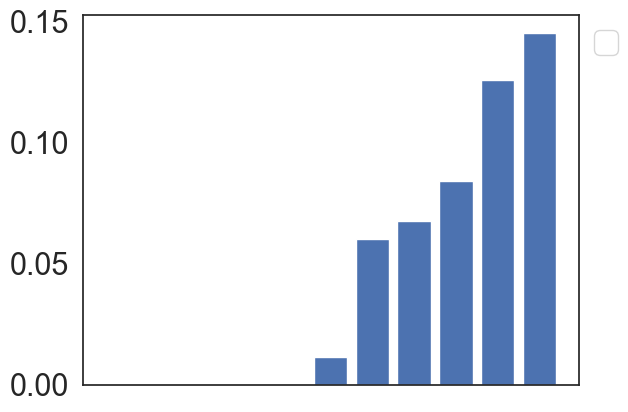

In [133]:
patient_list = []
tr_cell_category = []
for i in adata[~(adata.obs['clonotype_patient'].isin(tr_clonotype_patient)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient']:
    patient_list.append(i.split('_')[1])
    if i in shared_clones_bf1f2:
        tr_cell_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        tr_cell_category.append('Other')
    elif i in shared_clones_f1f2_only:
        tr_cell_category.append('Other')
    elif i in b_clonotypes:
        tr_cell_category.append('Other')
    elif i in f1_clonotypes:
        tr_cell_category.append('Other')
    elif i in f2_clonotypes:
        tr_cell_category.append('Other')
    else:
        tr_cell_category.append('Other')
temp_fast = pd.DataFrame({
    'Patient' : pd.Series(patient_list),
    'TR Cell Category' : pd.Series(tr_cell_category)}).groupby('Patient').value_counts().reset_index().pivot(index='Patient',
                                                                                                            columns='TR Cell Category',
                                                                                                            values=0).fillna(0).sort_values(by='All Timepoints Shared')
temp_fast = temp_fast.div(temp_fast.sum(axis=1),axis=0)
temp_fast = temp_fast.sort_values(by='All Timepoints Shared')
plt.bar(data=temp_fast,x=temp_fast.index,height='All Timepoints Shared')
plt.legend(bbox_to_anchor=(1,1))
plt.xticks([])

In [134]:
temp_all

TR Cell Category,All Timepoints Shared,Other,Progression,Progression Color
Patient,,,,
E14,0.000000,1.000000,Fast,tab:orange
E19,0.000000,1.000000,Fast,tab:orange
E27,0.000000,1.000000,Fast,tab:orange
E30,0.000000,1.000000,Fast,tab:orange
E31,0.000000,1.000000,Fast,tab:orange
E34,0.000000,1.000000,Fast,tab:orange
E43,0.000000,1.000000,Fast,tab:orange
E44,0.000000,1.000000,Fast,tab:orange
E16,0.484076,0.515924,Fast,tab:orange


In [135]:
temp

E21    752
E18    487
E22    406
E16    314
E17    219
E23    188
E39    162
E41    146
E29    123
E42    113
E12     83
E34     80
E43     70
E20     59
E40     59
E38     56
E35     45
E27     43
E26     27
E31     27
E15     27
E19     18
E46     14
E24     10
E30      8
E14      5
E36      4
E44      4
E32      2
E37      1
Name: patient, dtype: int64

In [136]:
temp_fast

TR Cell Category,All Timepoints Shared,Other
Patient,,
E14,0.000000,1.000000
E19,0.000000,1.000000
E30,0.000000,1.000000
E34,0.000000,1.000000
E43,0.000000,1.000000
E45,0.011407,0.988593
E27,0.060091,0.939909
E44,0.067669,0.932331
E25,0.084101,0.915899


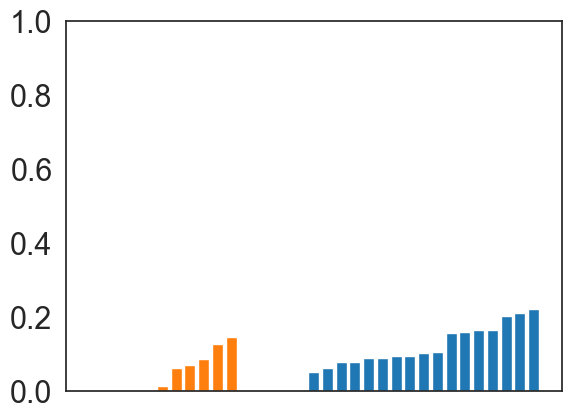

In [137]:
temp_all = pd.concat([temp_fast,temp_slow],axis=0)
temp_all = temp_all.div(temp_all.sum(axis=1),axis=0)
temp_all['Progression'] = temp_all.index.astype(str).map(patient_progression)
temp_all['Progression Color'] = temp_all['Progression'].map({'Fast' : 'tab:orange',
                                                             'Slow' : 'tab:blue'})
plt.bar(data=temp_all,x=temp_all.index,height='All Timepoints Shared',
       color='Progression Color',label='Progression')
plt.xticks([])
plt.ylim([0,1])
plt.show()

/tmp/ipykernel_276854/1207964539.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=temp_all,x='Progression',y='All Timepoints Shared',


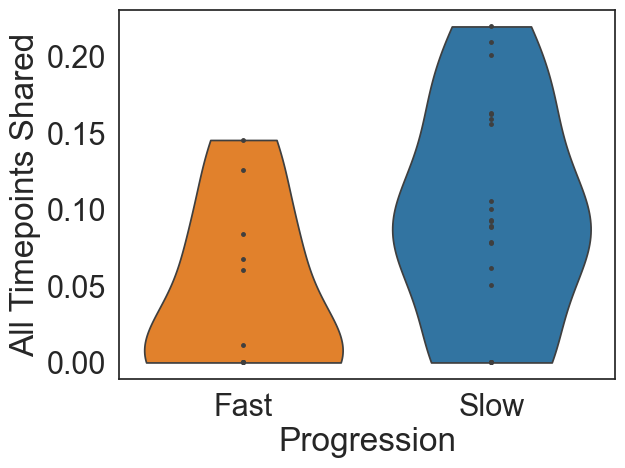

In [138]:
sns.violinplot(data=temp_all,x='Progression',y='All Timepoints Shared',
              palette={'Fast':'tab:orange','Slow':'tab:blue'},cut=0,inner='points')
plt.show()

In [139]:
from scipy.stats import ranksums
ranksums(temp_all[temp_all['Progression'] == 'Slow']['All Timepoints Shared'],
temp_all[temp_all['Progression'] == 'Fast']['All Timepoints Shared'])

RanksumsResult(statistic=1.9667570271120685, pvalue=0.04921122893950836)

In [137]:
from scipy.stats import ranksums
ranksums(temp_all[temp_all['Progression'] == 'Slow']['All Timepoints Shared'],
temp_all[temp_all['Progression'] == 'Fast']['All Timepoints Shared'])

RanksumsResult(statistic=1.9667570271120685, pvalue=0.04921122893950836)

In [138]:
colors = {
    'All Timepoints Shared' : plt.matplotlib.colors.to_rgba('tab:blue', alpha=1),
    'B-F1 Shared Only' : plt.matplotlib.colors.to_rgba('tab:orange', alpha=1),
    'F1-F2 Shared Only' : plt.matplotlib.colors.to_rgba('tab:green', alpha=1),
    'B Only' : plt.matplotlib.colors.to_rgba('tab:red', alpha=0.3),
    'F1 Only' : plt.matplotlib.colors.to_rgba('tab:purple', alpha=0.3),
    'F2 Only' : plt.matplotlib.colors.to_rgba('tab:brown', alpha=0.3),
    'B-F2 Shared Only' : plt.matplotlib.colors.to_rgba('tab:pink', alpha=1)
}

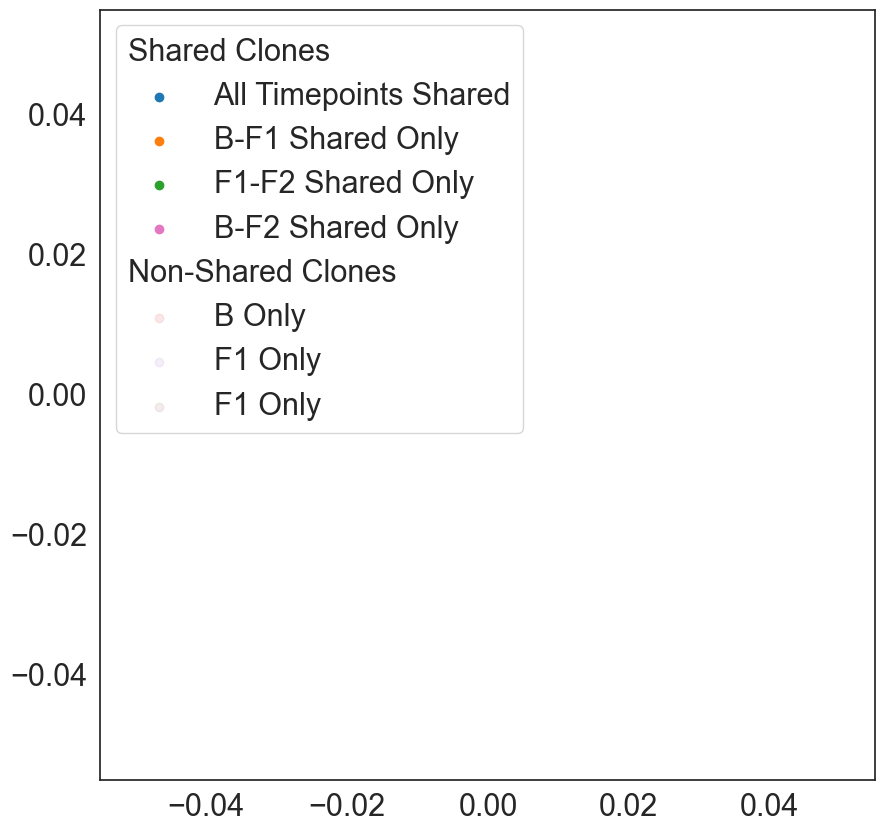

In [139]:
import matplotlib
#Ex1 posthoc center legend labels that have alpha=0
def center_subtitles(legend):
    """Centers legend labels with alpha=0
    """
    vpackers = legend.findobj(matplotlib.offsetbox.VPacker)
    for vpack in vpackers[:-1]: #Last vpack will be the title box
        vpack.align = 'left'
        for hpack in vpack.get_children():
            draw_area, text_area = hpack.get_children()
            for collection in draw_area.get_children():
                alpha = collection.get_alpha()
                sizes = collection.get_sizes()
                if alpha == 0 or all(sizes == 0):
                    draw_area.set_visible(False)
    return legend


def ex1_mpl_posthoc_centering():
    """Explicit call to center the legend subtitles
    """
    f, ax = plt.subplots(figsize=(10,10))
    
    h1 = ax.scatter([], [], alpha=0, label="Shared Clones")
    h2 = ax.scatter([], [], label="All Timepoints Shared",color=plt.matplotlib.colors.to_rgba('tab:blue', alpha=1))
    h3 = ax.scatter([], [], label="B-F1 Shared Only",color=plt.matplotlib.colors.to_rgba('tab:orange', alpha=1))
    h4 = ax.scatter([], [], label="F1-F2 Shared Only",color=plt.matplotlib.colors.to_rgba('tab:green', alpha=1))
    h5 = ax.scatter([], [], label="B-F2 Shared Only",color=plt.matplotlib.colors.to_rgba('tab:pink', alpha=1))
    h6 = ax.scatter([], [], alpha=0, label="Non-Shared Clones")
    h7 = ax.scatter([], [], label="B Only",color=plt.matplotlib.colors.to_rgba('tab:red', alpha=0.1))
    h8 = ax.scatter([], [], label="F1 Only",color=plt.matplotlib.colors.to_rgba('tab:purple', alpha=0.1))
    h9 = ax.scatter([], [], label="F1 Only",color=plt.matplotlib.colors.to_rgba('tab:brown', alpha=0.1))

    ax_legend = ax.legend(loc="upper left")
    
    #Center legend labels w/ alpha==0
    center_subtitles(ax_legend)
    
    plt.show()

ex1_mpl_posthoc_centering()

In [140]:
temp = adata[~(adata.obs['clonotype_patient'].isin(tr_clonotype_patient))].copy()
temp.obs['annot_final'] = temp.obs['annot_final'].replace('GZMK+ CD8 T progrenitor ex Cell','GZMK+ CD8 T progenitor ex Cell')

In [141]:
temp.obs['timepoint_progression'] = temp.obs['timepoint'].astype(str) + '_' + temp.obs['progression'].astype(str)

In [142]:
temp.obs['patient_clonotype'] = temp.obs['patient'].astype(str) + '_' + temp.obs['clonotype'].astype(str)

In [143]:
temp_dict = {}
b_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_fast.append(proportions)
b_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_slow.append(proportions)
f1_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_fast.append(proportions)
f1_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_slow.append(proportions)
f2_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_fast.append(proportions)
f2_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts()
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_slow.append(proportions)
temp_dict['B_Fast'] = pd.DataFrame(b_fast).mean(axis=0)
temp_dict['B_Slow'] = pd.DataFrame(b_slow).mean(axis=0)
temp_dict['F1_Fast'] = pd.DataFrame(f1_fast).mean(axis=0)
temp_dict['F1_Slow'] = pd.DataFrame(f1_slow).mean(axis=0)
temp_dict['F2_Fast'] = pd.DataFrame(f2_fast).mean(axis=0)
temp_dict['F2_Slow'] = pd.DataFrame(f2_slow).mean(axis=0)

In [144]:
temp_df = pd.DataFrame(temp_dict).sort_values(by='B_Fast')
temp_df_old = temp_df.copy()

In [145]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

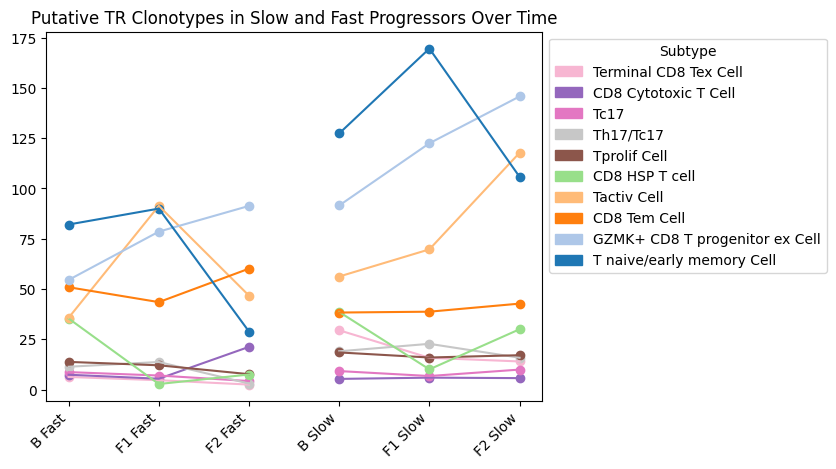

In [146]:
sns.reset_defaults()
patches = []
for i in temp_df_old.index.tolist():
    if i == 'NKT' or i == 'gd T Cell':
        continue
    else:
        plt.scatter([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        plt.plot([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        
        plt.scatter([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
        plt.plot([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
    
    patches.append(mpatches.Patch(color=color_dict[i], label=i))

plt.legend(handles=patches,bbox_to_anchor=(1,1),title='Subtype')

plt.xticks([1,2,3,4,5,6], ['B Fast', 'F1 Fast', 'F2 Fast',
                           'B Slow', 'F1 Slow', 'F2 Slow'],rotation=45,ha='right')
plt.title('Putative TR Clonotypes in Slow and Fast Progressors Over Time')
plt.show()

In [147]:
temp = adata[~(adata.obs['clonotype_patient'].isin(tr_clonotype_patient))].copy()
temp.obs['annot_final'] = temp.obs['annot_final'].replace('GZMK+ CD8 T progrenitor ex Cell','GZMK+ CD8 T progenitor ex Cell')

In [148]:
temp.obs['timepoint_progression'] = temp.obs['timepoint'].astype(str) + '_' + temp.obs['progression'].astype(str)

In [149]:
temp.obs['patient_clonotype'] = temp.obs['patient'].astype(str) + '_' + temp.obs['clonotype'].astype(str)

In [150]:
temp_dict = {}
b_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_fast.append(proportions)
b_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_slow.append(proportions)
f1_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_fast.append(proportions)
f1_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_slow.append(proportions)
f2_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_fast.append(proportions)
f2_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_slow.append(proportions)
temp_dict['B_Fast'] = pd.DataFrame(b_fast).mean(axis=0)
temp_dict['B_Slow'] = pd.DataFrame(b_slow).mean(axis=0)
temp_dict['F1_Fast'] = pd.DataFrame(f1_fast).mean(axis=0)
temp_dict['F1_Slow'] = pd.DataFrame(f1_slow).mean(axis=0)
temp_dict['F2_Fast'] = pd.DataFrame(f2_fast).mean(axis=0)
temp_dict['F2_Slow'] = pd.DataFrame(f2_slow).mean(axis=0)

In [151]:
temp_df = pd.DataFrame(temp_dict).sort_values(by='B_Fast')
temp_df_old = temp_df.copy()

In [152]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

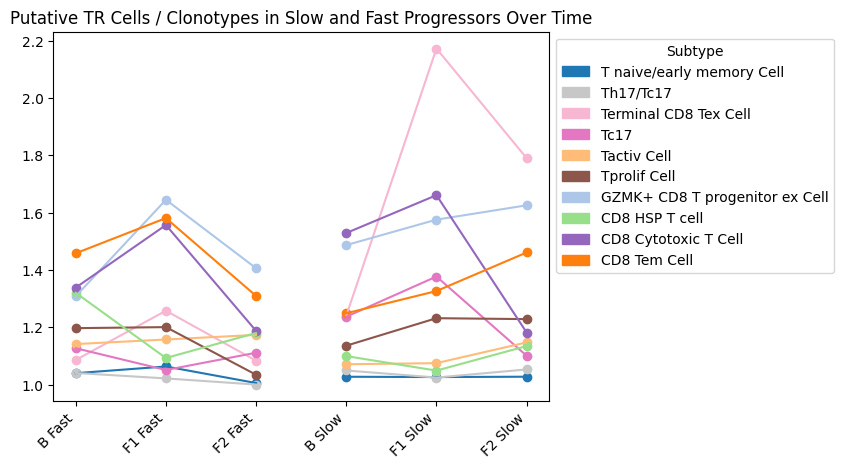

In [153]:
sns.reset_defaults()
patches = []
for i in temp_df_old.index.tolist():
    if i == 'NKT' or i == 'gd T Cell':
        continue
    else:
        plt.scatter([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        plt.plot([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        
        plt.scatter([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
        plt.plot([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
    
    patches.append(mpatches.Patch(color=color_dict[i], label=i))

plt.legend(handles=patches,bbox_to_anchor=(1,1),title='Subtype')

plt.xticks([1,2,3,4,5,6], ['B Fast', 'F1 Fast', 'F2 Fast',
                           'B Slow', 'F1 Slow', 'F2 Slow'],rotation=45,ha='right')
plt.title('Putative TR Cells / Clonotypes in Slow and Fast Progressors Over Time')
plt.show()

In [154]:
cell_proportion = {}
clonotype_proportion = {}
progression = {}
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    progression[i] = temp.obs['progression'][0]
    cell_proportion[i] = len(temp[temp.obs['clonotype_patient'].isin(tr_clonotype_patient)]) / len(temp)
    clonotype_proportion[i] = len(temp[temp.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs['clonotype_patient'].unique()) / len(temp.obs['clonotype_patient'].unique())

In [155]:
proportion_df = pd.concat([pd.Series(cell_proportion),
           pd.Series(clonotype_proportion),
           pd.Series(progression)],axis=1)
proportion_df.columns = ['TR Cell Proportion',
                         'TR Clonotype Proportion',
                         'Progression']
proportion_df['Timepoint'] = [i.split('_')[1] for i in proportion_df.index.tolist()]

In [156]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'B'].sort_values(by='Progression'),
            y='TR Cell Proportion',x=proportion_df[proportion_df['Timepoint'] == 'B'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of cells in each patient that are TR, B')

Text(0.5, 1.0, 'Proportion of cells in each patient that are TR, B')

In [157]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'F1'].sort_values(by=['Progression']),
            y='TR Cell Proportion',x=proportion_df[proportion_df['Timepoint'] == 'F1'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of cells in each patient that are TR, F1')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


Text(0.5, 1.0, 'Proportion of cells in each patient that are TR, F1')

In [158]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'F2'].sort_values(by='Progression'),
            y='TR Cell Proportion',x=proportion_df[proportion_df['Timepoint'] == 'F2'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of cells in each patient that are TR, F2')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


Text(0.5, 1.0, 'Proportion of cells in each patient that are TR, F2')

In [159]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'B'].sort_values(by='Progression'),
            y='TR Clonotype Proportion',x=proportion_df[proportion_df['Timepoint'] == 'B'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of clonotypes in each patient that are TR, B')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


Text(0.5, 1.0, 'Proportion of clonotypes in each patient that are TR, B')

In [160]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'F1'].sort_values(by='Progression'),
            y='TR Clonotype Proportion',x=proportion_df[proportion_df['Timepoint'] == 'F1'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of clonotypes in each patient that are TR, F1')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


Text(0.5, 1.0, 'Proportion of clonotypes in each patient that are TR, F1')

In [161]:
sns.barplot(data=proportion_df[proportion_df['Timepoint'] == 'F2'].sort_values(by='Progression'),
            y='TR Clonotype Proportion',x=proportion_df[proportion_df['Timepoint'] == 'F2'].index,
           hue='Progression',hue_order=['Slow','Fast'])
plt.xticks([])
plt.xlabel('')
plt.title('Proportion of clonotypes in each patient that are TR, F2')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


Text(0.5, 1.0, 'Proportion of clonotypes in each patient that are TR, F2')

In [162]:
adata.obs['TR_nonTR'].value_counts().loc['TR']/ len(adata)

0.06399308182899147

In [163]:
adata.obs['TR_nonTR'].value_counts().loc['TR']

3552

In [164]:
len(adata)

55506

In [165]:
adata.obs[['TR_nonTR','clonotype_patient']].drop_duplicates()['TR_nonTR'].value_counts().loc['TR'] / len(adata.obs[['TR_nonTR','clonotype_patient']].drop_duplicates())

0.010986603230249154

In [166]:
adata.obs[['TR_nonTR','clonotype_patient']].drop_duplicates()['TR_nonTR'].value_counts().loc['TR']

351

In [167]:
len(adata.obs[['TR_nonTR','clonotype_patient']].drop_duplicates())

31948

In [168]:
proportion_df.to_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tr_sample_proportions.csv')

# New Clones

## F1

In [169]:
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()
clonotypes_b = adata[adata.obs['timepoint'] == 'B'].obs['clonotype_patient'].unique().tolist()

In [170]:
new_f1_clonotypes = [i for i in clonotypes_f1 if i not in clonotypes_b]

In [171]:
clonotype_counts_f1 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F1') & (
    adata.obs['clonotype_patient'].isin(new_f1_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [172]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [173]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [174]:
f1_props = []
for i in clonotype_counts_f1.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f1_props.append(clonotype_counts_f1.loc[i,'clonotype_patient'] / f1_count)

In [175]:
clonotype_counts_f1_norm = pd.DataFrame({'F1' : f1_props},index=clonotype_counts_f1.index)

In [176]:
expanding_clones = [i for i in clonotype_counts_f1_norm.index if clonotype_counts_f1_norm.loc[i,'F1'] > 0]

In [177]:
len(expanding_clones)

11610

In [178]:
new_clones_f1 = expanding_clones

## F2

In [179]:
clonotypes_f2 = adata[adata.obs['timepoint'] == 'F2'].obs['clonotype_patient'].unique().tolist()
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()

In [180]:
new_f2_clonotypes = [i for i in clonotypes_f2 if i not in clonotypes_f1]

In [181]:
clonotype_counts_f2 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F2') & (
    adata.obs['clonotype_patient'].isin(new_f2_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [182]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [183]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [184]:
f2_props = []
for i in clonotype_counts_f2.index:
    temp = i.split('_')[1]
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f2_props.append(clonotype_counts_f2.loc[i,'clonotype_patient'] / f2_count)

In [185]:
clonotype_counts_f2_norm = pd.DataFrame({'F2' : f2_props},index=clonotype_counts_f2.index)

In [186]:
expanding_clones = [i for i in clonotype_counts_f2_norm.index if clonotype_counts_f2_norm.loc[i,'F2'] > 0]

In [187]:
len(clonotype_counts_f2_norm)

9599

In [188]:
len(expanding_clones)

9599

In [189]:
new_clones_f2 = expanding_clones

# Put clonotypes together

In [199]:
adata.obs['annot_final'].unique().tolist()

['CD8 Tem Cell',
 'Tactiv Cell',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'Terminal CD8 Tex Cell']

In [200]:
adata_sub = adata[adata.obs['annot_final'] != 'T naive/early memory Cell']

In [201]:
sharing_category = {}
for i in adata_sub.obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        sharing_category[i] = 'All Timepoints Shared'
    elif i in shared_clones_bf1_only:
        sharing_category[i] = 'B-F1 Shared Only'
    elif i in shared_clones_f1f2_only:
        sharing_category[i] = 'F1-F2 Shared Only'
    elif i in b_clonotypes:
        sharing_category[i] = 'B Only'
    elif i in f1_clonotypes:
        sharing_category[i] = 'F1 Only'
    elif i in f2_clonotypes:
        sharing_category[i] = 'F2 Only'
    else:
        sharing_category[i] = 'B-F2 Shared Only'

In [202]:
new_category = {}
for i in adata_sub.obs['clonotype_patient'].unique():
    if i in new_clones_f1:
        new_category[i] = 'New F1'
    elif i in new_clones_f2:
        new_category[i] = 'New F2'
    else:
        new_category[i] = 'Not New'

In [203]:
temp = adata_sub.obs[['clonotype_patient','IR_VJ_1_junction_aa','IR_VDJ_1_junction_aa',]].drop_duplicates()
alpha_cdr3 = {}
beta_cdr3 = {}
for i in adata_sub.obs['clonotype_patient'].unique():
    beta_cdr3[i] = temp[temp['clonotype_patient'] == i]['IR_VDJ_1_junction_aa'][0]
    alpha_cdr3[i] = temp[temp['clonotype_patient'] == i]['IR_VJ_1_junction_aa'][0]

In [204]:
temp = adata_sub.obs[['clonotype_patient','TR_nonTR']].drop_duplicates()
TR = {}
for i in adata_sub.obs['clonotype_patient'].unique():
    TR[i] = temp[temp['clonotype_patient'] == i]['TR_nonTR'][0]

In [205]:
temp = adata_sub.obs[['clonotype_patient','progression']].drop_duplicates()
progression = {}
for i in adata_sub.obs['clonotype_patient'].unique():
    progression[i] = temp[temp['clonotype_patient'] == i]['progression'][0]

In [206]:
seq_df = pd.DataFrame({
    'Alpha CDR3' : alpha_cdr3,
    'Beta CDR3' : beta_cdr3,
    'TR Status' : TR,
    'Sharing Status' : sharing_category,
    'New Status' : new_category,
    'Progression' : progression
})

In [207]:
seq_df['Patient'] = [i.split('_')[1] for i in seq_df.index]

In [208]:
seq_df.to_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/blood_tcr_analysis/single_cell_sequences_wo_t_naive_early_memory.csv')

# Covariation with other TME features

In [140]:
temp

E21    752
E18    487
E22    406
E16    314
E17    219
E23    188
E39    162
E41    146
E29    123
E42    113
E12     83
E34     80
E43     70
E20     59
E40     59
E38     56
E35     45
E27     43
E26     27
E31     27
E15     27
E19     18
E46     14
E24     10
E30      8
E14      5
E36      4
E44      4
E32      2
E37      1
Name: patient, dtype: int64

In [141]:
b_tr_props = {}
f1_tr_props = {}
f2_tr_props = {}
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    if '_B' in i:
        if 'TR' in temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts().index.tolist():
            b_tr_props[i] = (temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts() / len(temp)).loc['TR']
        else:
            b_tr_props[i] = 0
    elif '_F1' in i:
        if 'TR' in temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts().index.tolist():
            f1_tr_props[i] = (temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts() / len(temp)).loc['TR']
        else:
            f1_tr_props[i] = 0
    else:
        if 'TR' in temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts().index.tolist():
            f2_tr_props[i] = (temp[temp.obs['clonotype_patient'].isin(shared_clones_bf1f2)].obs['TR_nonTR'].value_counts() / len(temp)).loc['TR']
        else:
            f2_tr_props[i] = 0

In [142]:
adata_tme = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot_new.h5ad')

In [143]:
adata_b = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_b_annotation.h5ad')

In [144]:
adata_tme.obs['annot_final'] = pd.concat([
    adata_tme[adata_tme.obs['annot_final'] != 'B'].obs['annot_final'],
    adata_b.obs['annot_3rd']
])

In [145]:
pd.Series(b_tr_props).sort_index()

E12_B    0.067308
E14_B    0.000000
E15_B    0.000000
E16_B    0.052158
E17_B    0.017606
E18_B    0.066531
E19_B    0.000000
E20_B    0.000000
E21_B    0.237258
E22_B    0.045603
E23_B    0.060150
E24_B    0.000000
E25_B    0.000000
E26_B    0.000000
E27_B    0.000000
E29_B    0.000000
E30_B    0.000000
E31_B    0.000000
E32_B    0.000000
E33_B    0.000000
E34_B    0.000000
E35_B    0.002770
E36_B    0.000000
E37_B    0.000000
E38_B    0.006245
E39_B    0.087629
E40_B    0.000000
E41_B    0.030113
E42_B    0.034146
E43_B    0.000000
E44_B    0.000000
E45_B    0.000000
E46_B    0.000000
dtype: float64

In [146]:
adata_tme.obs['annot_final'].unique().tolist()

['Plasma',
 'Activated B Cell',
 'Resting Memory B Cell',
 'Naive B Cell',
 'Atypical Memory B Cell',
 'GC/Proliferative B Cell',
 'EIF6+ B Cell',
 'Epithelial',
 'Capillary Endothelial',
 'Pericyte',
 'iCAF',
 'Venuous Endothelial',
 'SMC',
 'Schwann',
 'Lymphatic Endothelial',
 'C1QC Macrophage',
 'cDC2',
 'Monocyte',
 'CD14 Monocyte',
 'Mast',
 'mregDC',
 'SPP1 Macrophage',
 'cDC1',
 'pDC',
 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'NK',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']

In [147]:
cell_type_counts = adata_tme.obs[['sample','annot_final']].value_counts().reset_index().pivot(
    index='sample',columns='annot_final',values=0
).fillna(0)
cell_type_props = cell_type_counts.div(cell_type_counts.sum(axis=1),axis=0)

In [148]:
len(cell_type_props.columns)

39

In [149]:
b_counts = cell_type_counts[['Activated B Cell',
 'Resting Memory B Cell',
 'Naive B Cell',
 'Atypical Memory B Cell',
 'GC/Proliferative B Cell',
 'EIF6+ B Cell']]
b_props = b_counts.div(b_counts.sum(axis=1),axis=0)

In [150]:
t_counts = cell_type_counts[['Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']]
t_props = t_counts.div(t_counts.sum(axis=1),axis=0)

In [151]:
stromal_counts = cell_type_counts[['Capillary Endothelial',
 'Pericyte',
 'iCAF',
 'Venuous Endothelial',
 'SMC',
 'Schwann',
 'Lymphatic Endothelial']]
stromal_props = stromal_counts.div(stromal_counts.sum(axis=1),axis=0)

In [152]:
myeloid_counts = cell_type_counts[['C1QC Macrophage',
 'cDC2',
 'Monocyte',
 'CD14 Monocyte',
 'Mast',
 'mregDC',
 'SPP1 Macrophage',
 'cDC1',
 'pDC']]
myeloid_props = myeloid_counts.div(myeloid_counts.sum(axis=1),axis=0)

In [153]:
extra_props = cell_type_props[['Epithelial','Plasma','NK']]

In [154]:
cell_type_props = pd.concat([b_props,t_props,stromal_props,myeloid_props,extra_props],axis=1)

In [155]:
cell_type_props

annot_final,Activated B Cell,Resting Memory B Cell,Naive B Cell,Atypical Memory B Cell,GC/Proliferative B Cell,EIF6+ B Cell,Treg,Tactiv Cell,CD8 Tem Cell,Th17,...,Monocyte,CD14 Monocyte,Mast,mregDC,SPP1 Macrophage,cDC1,pDC,Epithelial,Plasma,NK
sample,,,,,,,,,,,,,,,,,,,,,
E12_B,0.285714,0.657143,0.000000,0.057143,0.000000,0.000000,0.041899,0.122905,0.044693,0.011173,...,0.000000,0.056604,0.000000,0.056604,0.018868,0.000000,0.000000,0.174070,0.218487,0.019208
E12_F1,0.164912,0.536842,0.214035,0.073684,0.000000,0.010526,0.039573,0.146937,0.018238,0.003097,...,0.006645,0.272425,0.016611,0.056478,0.026578,0.003322,0.006645,0.151580,0.083853,0.010105
E12_F2,0.250653,0.532637,0.151436,0.054830,0.005222,0.005222,0.138482,0.109632,0.039947,0.011984,...,0.006211,0.096273,0.027950,0.040373,0.000000,0.024845,0.006211,0.095519,0.076179,0.017453
E14_B,0.234043,0.702128,0.042553,0.021277,0.000000,0.000000,0.065217,0.158385,0.083851,0.009317,...,0.016667,0.183333,0.000000,0.050000,0.016667,0.016667,0.000000,0.386839,0.150548,0.028913
E14_F1,0.111111,0.222222,0.400000,0.066667,0.177778,0.022222,0.180645,0.051613,0.074194,0.006452,...,0.000000,0.057692,0.019231,0.038462,0.000000,0.000000,0.057692,0.509786,0.099720,0.006524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E46_B_DN,0.329268,0.390244,0.195122,0.060976,0.000000,0.024390,0.072115,0.290064,0.342949,0.019231,...,0.000000,0.041096,0.027397,0.082192,0.000000,0.000000,0.000000,0.526834,0.095259,0.009839
E46_F1,0.405405,0.216216,0.324324,0.054054,0.000000,0.000000,0.102009,0.267388,0.092736,0.029366,...,0.035242,0.281938,0.008811,0.035242,0.185022,0.004405,0.000000,0.507246,0.043961,0.007246
E46_F1_AN,0.416667,0.416667,0.166667,0.000000,0.000000,0.000000,0.081602,0.209199,0.327893,0.025223,...,0.009709,0.029126,0.000000,0.077670,0.000000,0.009709,0.000000,0.337298,0.263083,0.006660


In [156]:
b_tr_cell_props = pd.concat(
    [pd.DataFrame({'TR' : b_tr_props}),cell_type_props],axis=1).dropna()
f1_tr_cell_props = pd.concat(
    [pd.DataFrame({'TR' : f1_tr_props}),cell_type_props],axis=1).dropna()
f2_tr_cell_props = pd.concat(
    [pd.DataFrame({'TR' : f2_tr_props}),cell_type_props],axis=1).dropna()

## All

In [157]:
sns.reset_defaults()

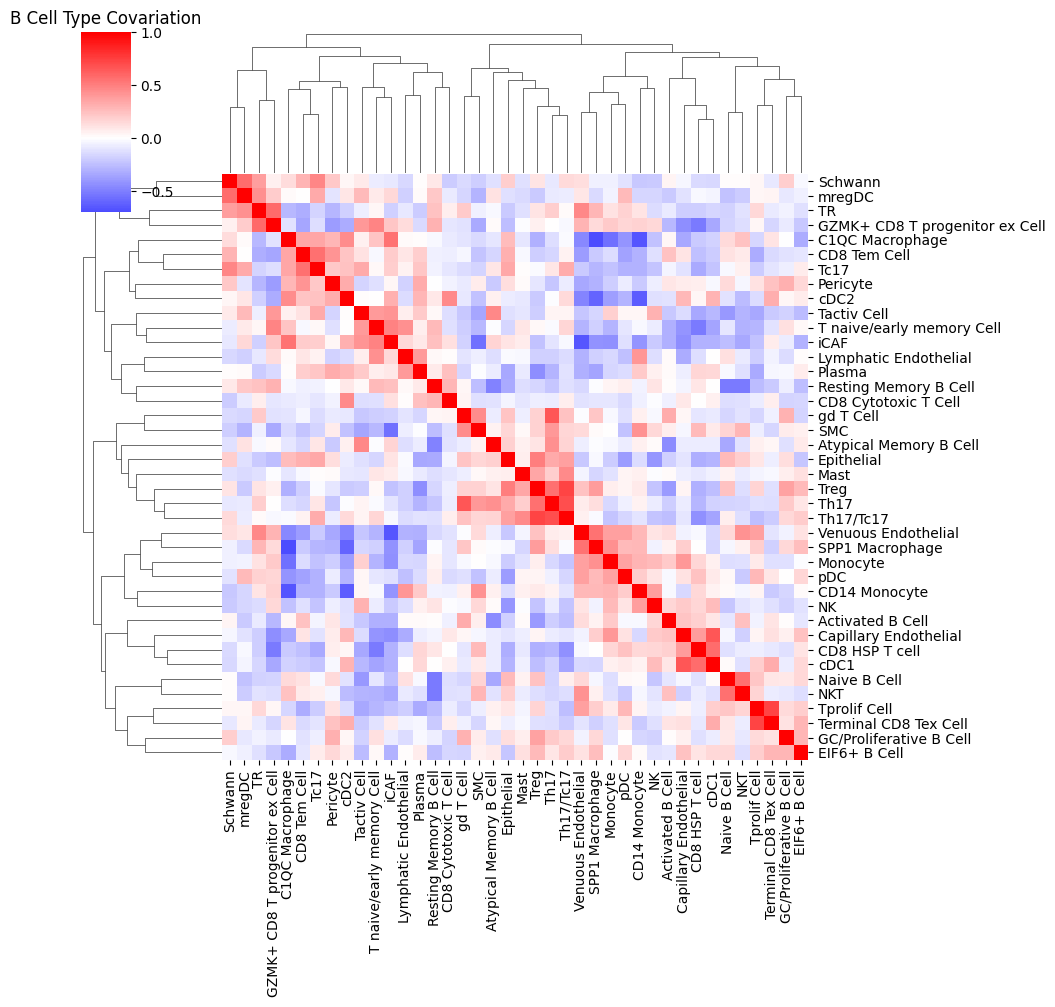

In [158]:
sns.clustermap(b_tr_cell_props.corr(),cmap='bwr',center=0,
              xticklabels=True,yticklabels=True)
plt.title('B Cell Type Covariation')
plt.show()

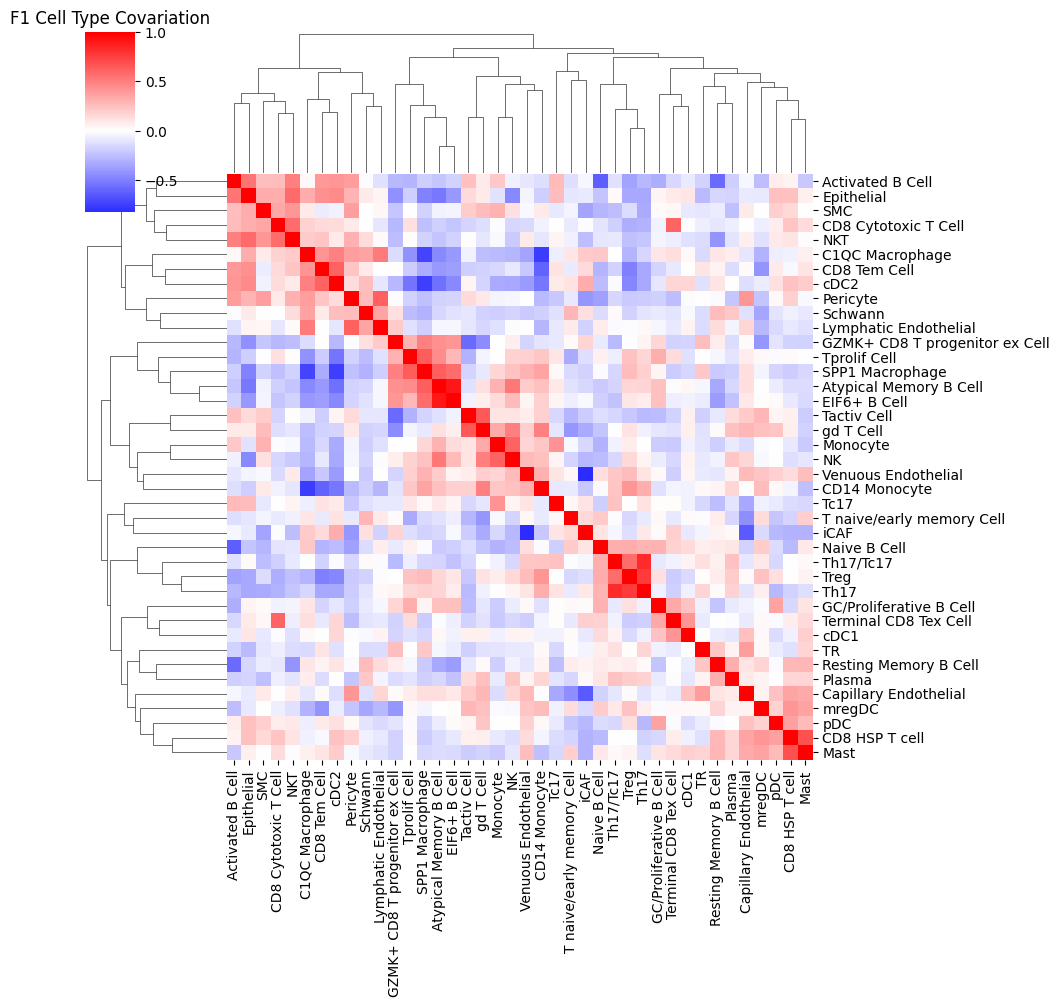

In [159]:
sns.clustermap(f1_tr_cell_props.corr(),cmap='bwr',center=0,
              xticklabels=True,yticklabels=True)
plt.title('F1 Cell Type Covariation')
plt.show()

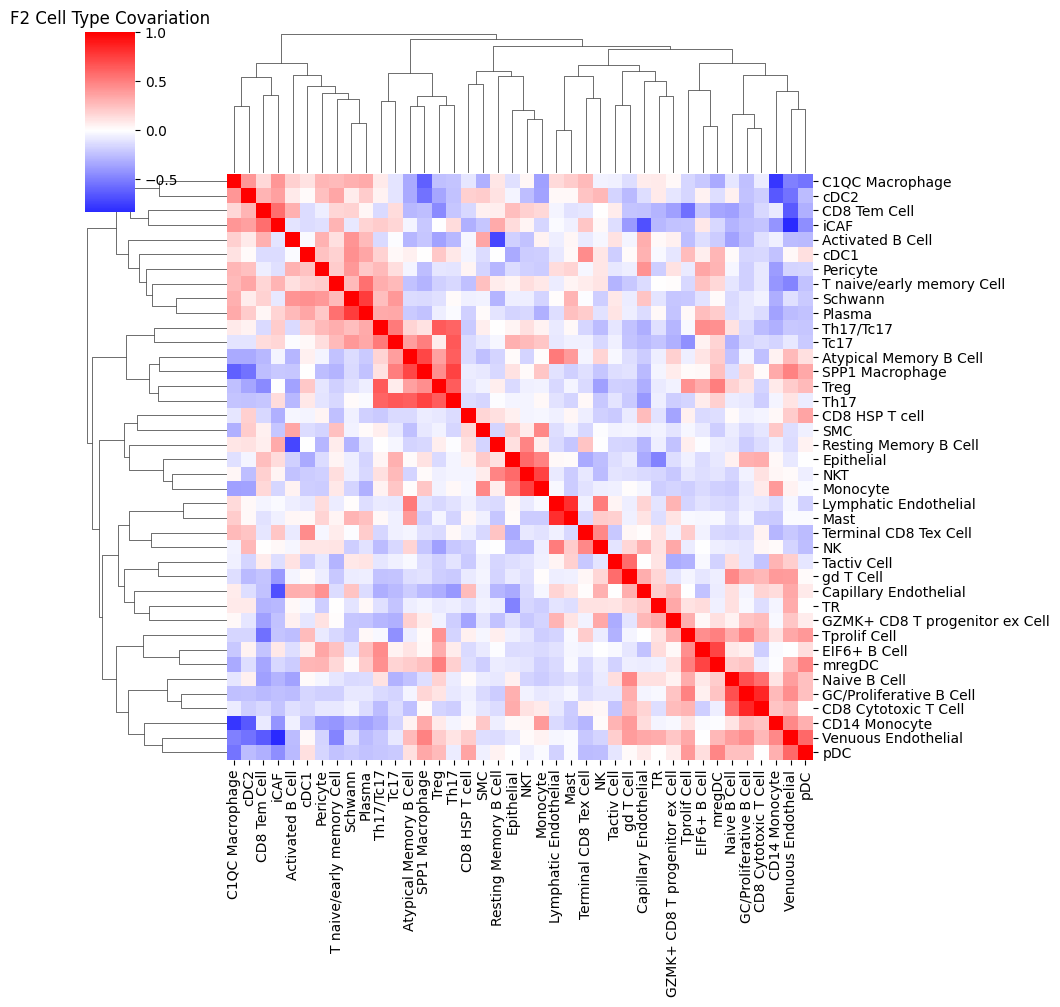

In [160]:
sns.clustermap(f2_tr_cell_props.corr().fillna(0),cmap='bwr',center=0,
              xticklabels=True,yticklabels=True)
plt.title('F2 Cell Type Covariation')
plt.show()